# Enterprise Sales Forecasting Pipeline
## ARIMA & Facebook Prophet Model Comparison for KPI Monitoring

This notebook implements a complete end-to-end sales forecasting solution with:
- Data cleaning and exploratory analysis
- ARIMA and Facebook Prophet models
- Model comparison (RMSE, MAE, MAPE)
- KPI dashboard with region-wise analysis
- Final forecast export and business recommendations

In [22]:
# Install missing packages
%pip install pandas numpy matplotlib seaborn statsmodels pmdarima prophet scikit-learn

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Time Series & Forecasting
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import math

# Set styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")

Note: you may need to restart the kernel to use updated packages.
✓ All libraries imported successfully!



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Section 1: Load & Understand Dataset

In [23]:
# Load the dataset
df = pd.read_csv(r'd:\project EPM\Enterprise Sales Forecasting\retail_store_inventory.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn Names & Types:")
print(df.dtypes)
print(f"\nDataset Info:")
print(df.info())

DATASET OVERVIEW

Dataset Shape: (73100, 15)

First 5 rows:
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy      

In [24]:
# Data Cleaning & Preparation
print("\n" + "=" * 80)
print("DATA CLEANING & PREPARATION")
print("=" * 80)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Calculate Profit (assuming Profit = (Units Sold * Price) - (Units Ordered * some cost factor))
# For this dataset, we'll estimate profit as Units Sold * Price * (1 - Discount/100)
df['Sales'] = df['Units Sold'] * df['Price']
df['Profit'] = df['Sales'] * (1 - df['Discount'] / 100)

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Check missing values
print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique Stores: {df['Store ID'].nunique()}")
print(f"Unique Products: {df['Product ID'].nunique()}")
print(f"Unique Regions: {df['Region'].nunique()} - {df['Region'].unique()}")
print(f"Categories: {df['Category'].unique()}")

print(f"\nBasic Statistics (Sales):")
print(df['Sales'].describe())
print(f"\nBasic Statistics (Profit):")
print(df['Profit'].describe())


DATA CLEANING & PREPARATION

Missing Values:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
Sales                 0
Profit                0
dtype: int64

Date Range: 2022-01-01 00:00:00 to 2024-01-01 00:00:00
Unique Stores: 5
Unique Products: 20
Unique Regions: 4 - ['North' 'East' 'West' 'South']
Categories: ['Groceries' 'Furniture' 'Electronics' 'Clothing' 'Toys']

Basic Statistics (Sales):
count    73100.000000
mean      7527.070929
std       7537.500441
min          0.000000
25%       2024.632500
50%       4956.090000
75%      10618.605000
max      47860.470000
Name: Sales, dtype: float64

Basic Statistics (Profit):
count    73100.000000
mean      6771.154240
std       6815.

## Section 2: Exploratory Data Analysis (EDA)


MONTHLY SALES AGGREGATION
        Date        Sales        Profit  Units Sold
0 2022-01-01  23260364.33  2.091953e+07      419938
1 2022-02-01  21184921.80  1.906103e+07      391052
2 2022-03-01  24004750.15  2.152268e+07      426073
3 2022-04-01  22610666.81  2.031440e+07      407380
4 2022-05-01  22814670.71  2.054256e+07      414799
5 2022-06-01  23252972.33  2.098179e+07      415509
6 2022-07-01  23598688.79  2.129391e+07      426628
7 2022-08-01  23355216.50  2.105528e+07      424916
8 2022-09-01  22884181.65  2.062891e+07      411610
9 2022-10-01  23459400.16  2.114750e+07      426863


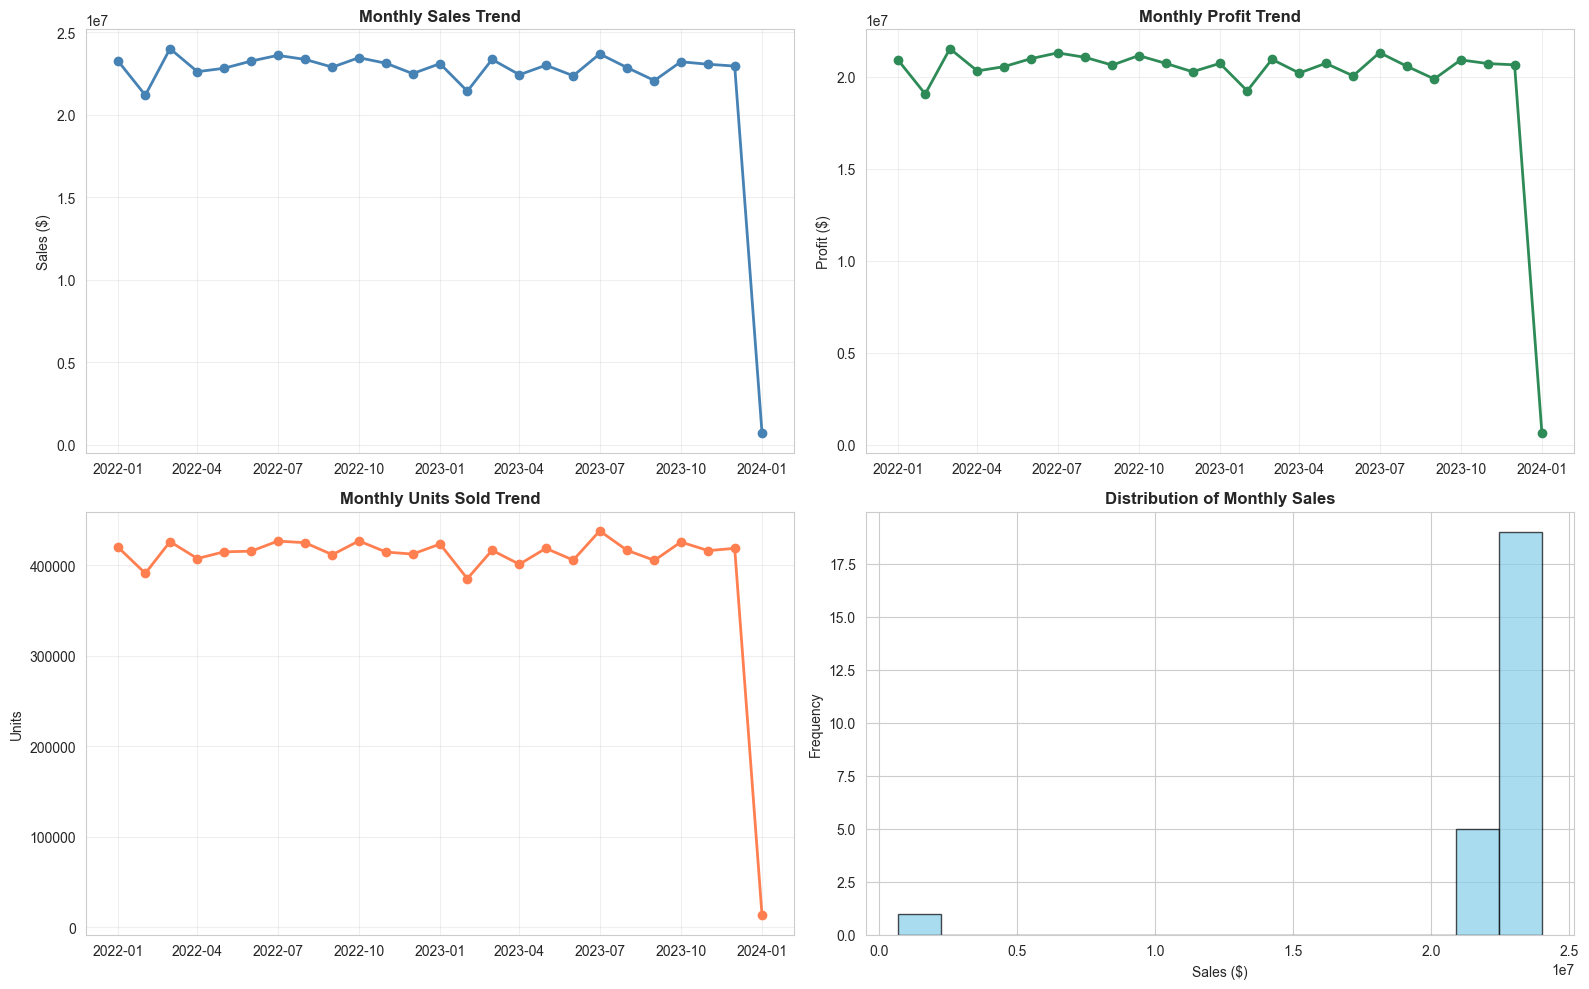


Monthly Sales Stats:
              Sales        Profit     Units Sold
count  2.500000e+01  2.500000e+01      25.000000
mean   2.200916e+07  1.979885e+07  399023.280000
std    4.489013e+06  4.036968e+06   81190.346535
min    6.881244e+05  6.281428e+05   13244.000000
25%    2.249354e+07  2.026814e+07  407380.000000
50%    2.300135e+07  2.071168e+07  416126.000000
75%    2.326036e+07  2.094469e+07  423408.000000
max    2.400475e+07  2.152268e+07  437919.000000


In [25]:
# Aggregate daily sales to monthly level
monthly_sales = df.groupby(df['Date'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Units Sold': 'sum'
}).reset_index()
monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()

print("\n" + "=" * 80)
print("MONTHLY SALES AGGREGATION")
print("=" * 80)
print(monthly_sales.head(10))

# Plot 1: Monthly Sales Time Series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Time Series
axes[0, 0].plot(monthly_sales['Date'], monthly_sales['Sales'], linewidth=2, color='steelblue', marker='o')
axes[0, 0].set_title('Monthly Sales Trend', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].grid(alpha=0.3)

# Profit Trend
axes[0, 1].plot(monthly_sales['Date'], monthly_sales['Profit'], linewidth=2, color='seagreen', marker='o')
axes[0, 1].set_title('Monthly Profit Trend', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Profit ($)')
axes[0, 1].grid(alpha=0.3)

# Units Sold
axes[1, 0].plot(monthly_sales['Date'], monthly_sales['Units Sold'], linewidth=2, color='coral', marker='o')
axes[1, 0].set_title('Monthly Units Sold Trend', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Units')
axes[1, 0].grid(alpha=0.3)

# Distribution
axes[1, 1].hist(monthly_sales['Sales'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Monthly Sales', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sales ($)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nMonthly Sales Stats:")
print(monthly_sales[['Sales', 'Profit', 'Units Sold']].describe())


REGIONAL SALES ANALYSIS
  Region         Sales        Profit  Units Sold  Transactions
0   East  1.387121e+08  1.247922e+08     2511265         18349
2  South  1.384836e+08  1.245674e+08     2507799         18297
1  North  1.372553e+08  1.235437e+08     2484966         18228
3   West  1.357780e+08  1.220681e+08     2471552         18226


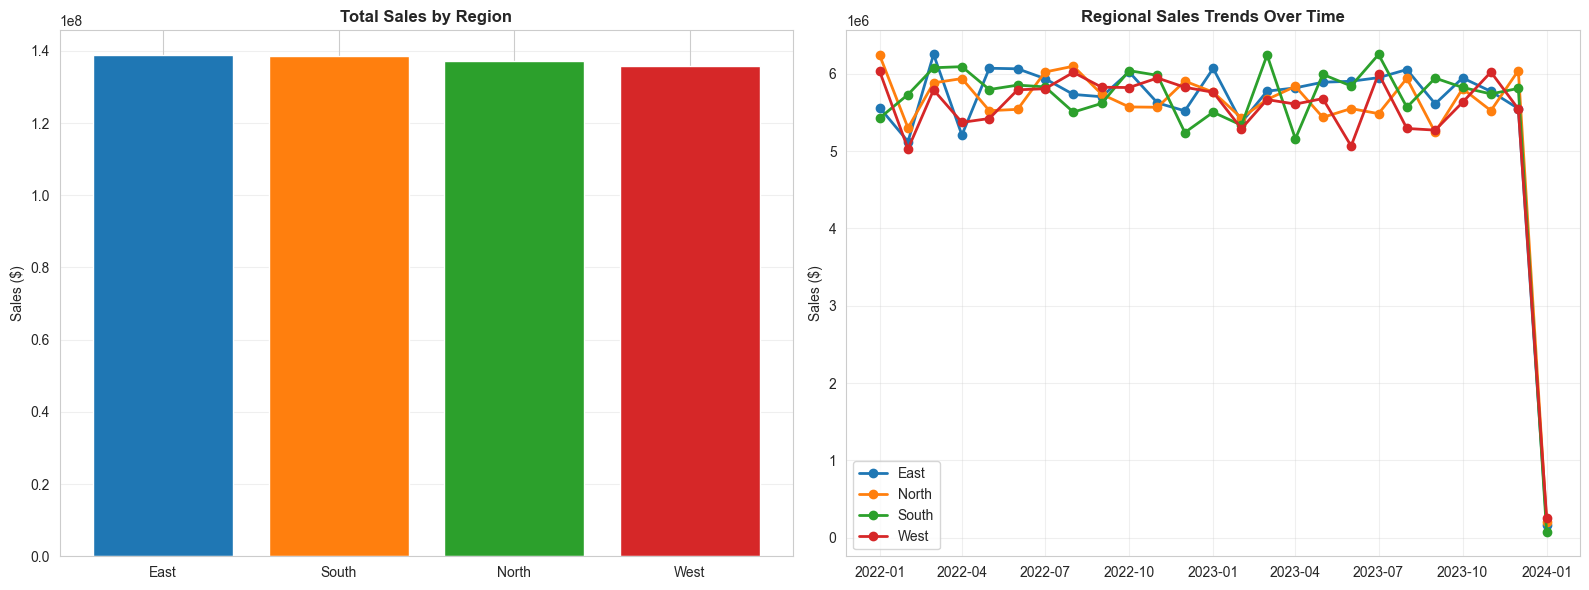

In [26]:
# Regional Analysis
regional_sales = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Units Sold': 'sum',
    'Date': 'count'  # Number of records
}).rename(columns={'Date': 'Transactions'}).reset_index().sort_values('Sales', ascending=False)

print("\n" + "=" * 80)
print("REGIONAL SALES ANALYSIS")
print("=" * 80)
print(regional_sales)

# Monthly sales by region
monthly_regional = df.groupby([df['Date'].dt.to_period('M'), 'Region']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()
monthly_regional['Date'] = monthly_regional['Date'].dt.to_timestamp()

# Plot 2: Region-wise Trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - Total sales by region
axes[0].bar(regional_sales['Region'], regional_sales['Sales'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Total Sales by Region', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(alpha=0.3, axis='y')

# Line plot - Sales trend by region
for region in monthly_regional['Region'].unique():
    region_data = monthly_regional[monthly_regional['Region'] == region]
    axes[1].plot(region_data['Date'], region_data['Sales'], marker='o', label=region, linewidth=2)
axes[1].set_title('Regional Sales Trends Over Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

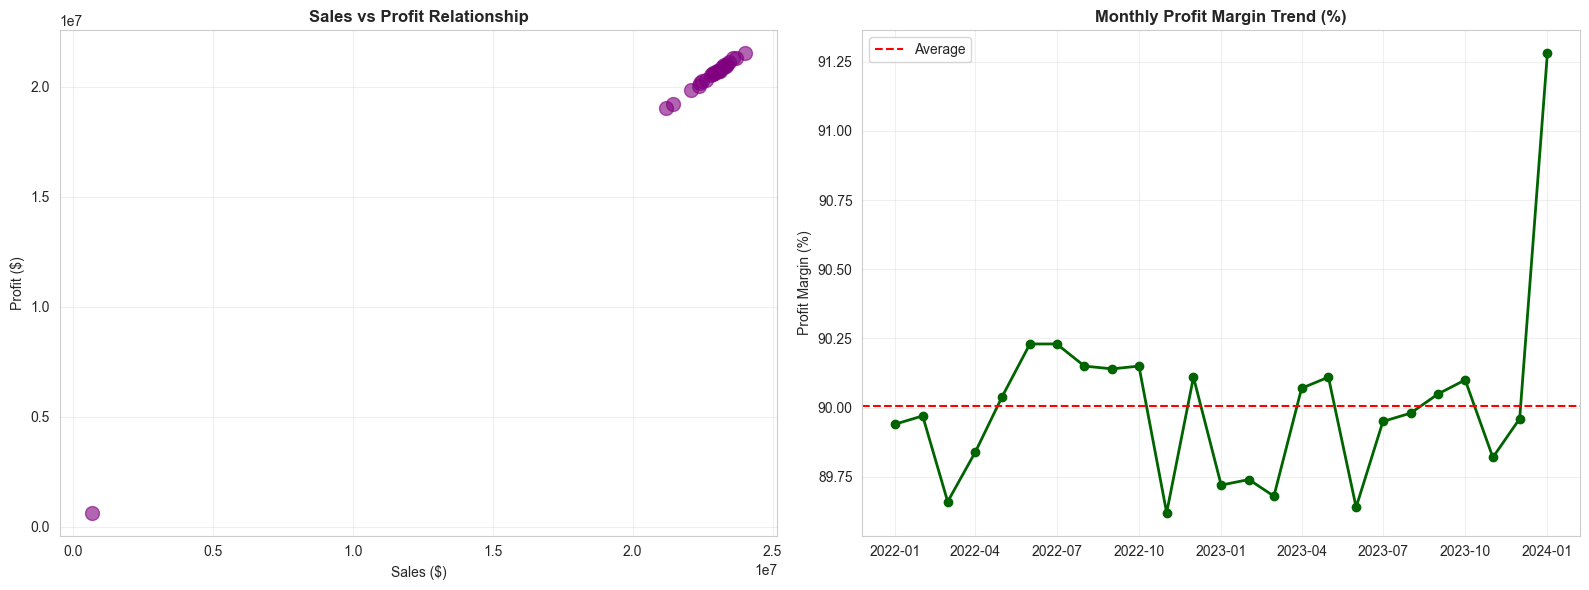


Profit Margin Statistics:
count    25.000000
mean     90.007200
std       0.326324
min      89.620000
25%      89.820000
50%      89.980000
75%      90.110000
max      91.280000
Name: Profit_Margin, dtype: float64


In [27]:
# Sales vs Profit Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(monthly_sales['Sales'], monthly_sales['Profit'], s=100, alpha=0.6, color='purple')
axes[0].set_title('Sales vs Profit Relationship', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Profit ($)')
axes[0].grid(alpha=0.3)

# Profit Margin trend
monthly_sales['Profit_Margin'] = (monthly_sales['Profit'] / monthly_sales['Sales'] * 100).round(2)
axes[1].plot(monthly_sales['Date'], monthly_sales['Profit_Margin'], linewidth=2, color='darkgreen', marker='o')
axes[1].set_title('Monthly Profit Margin Trend (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=monthly_sales['Profit_Margin'].mean(), color='red', linestyle='--', label='Average')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nProfit Margin Statistics:")
print(monthly_sales['Profit_Margin'].describe())


TIME SERIES DECOMPOSITION


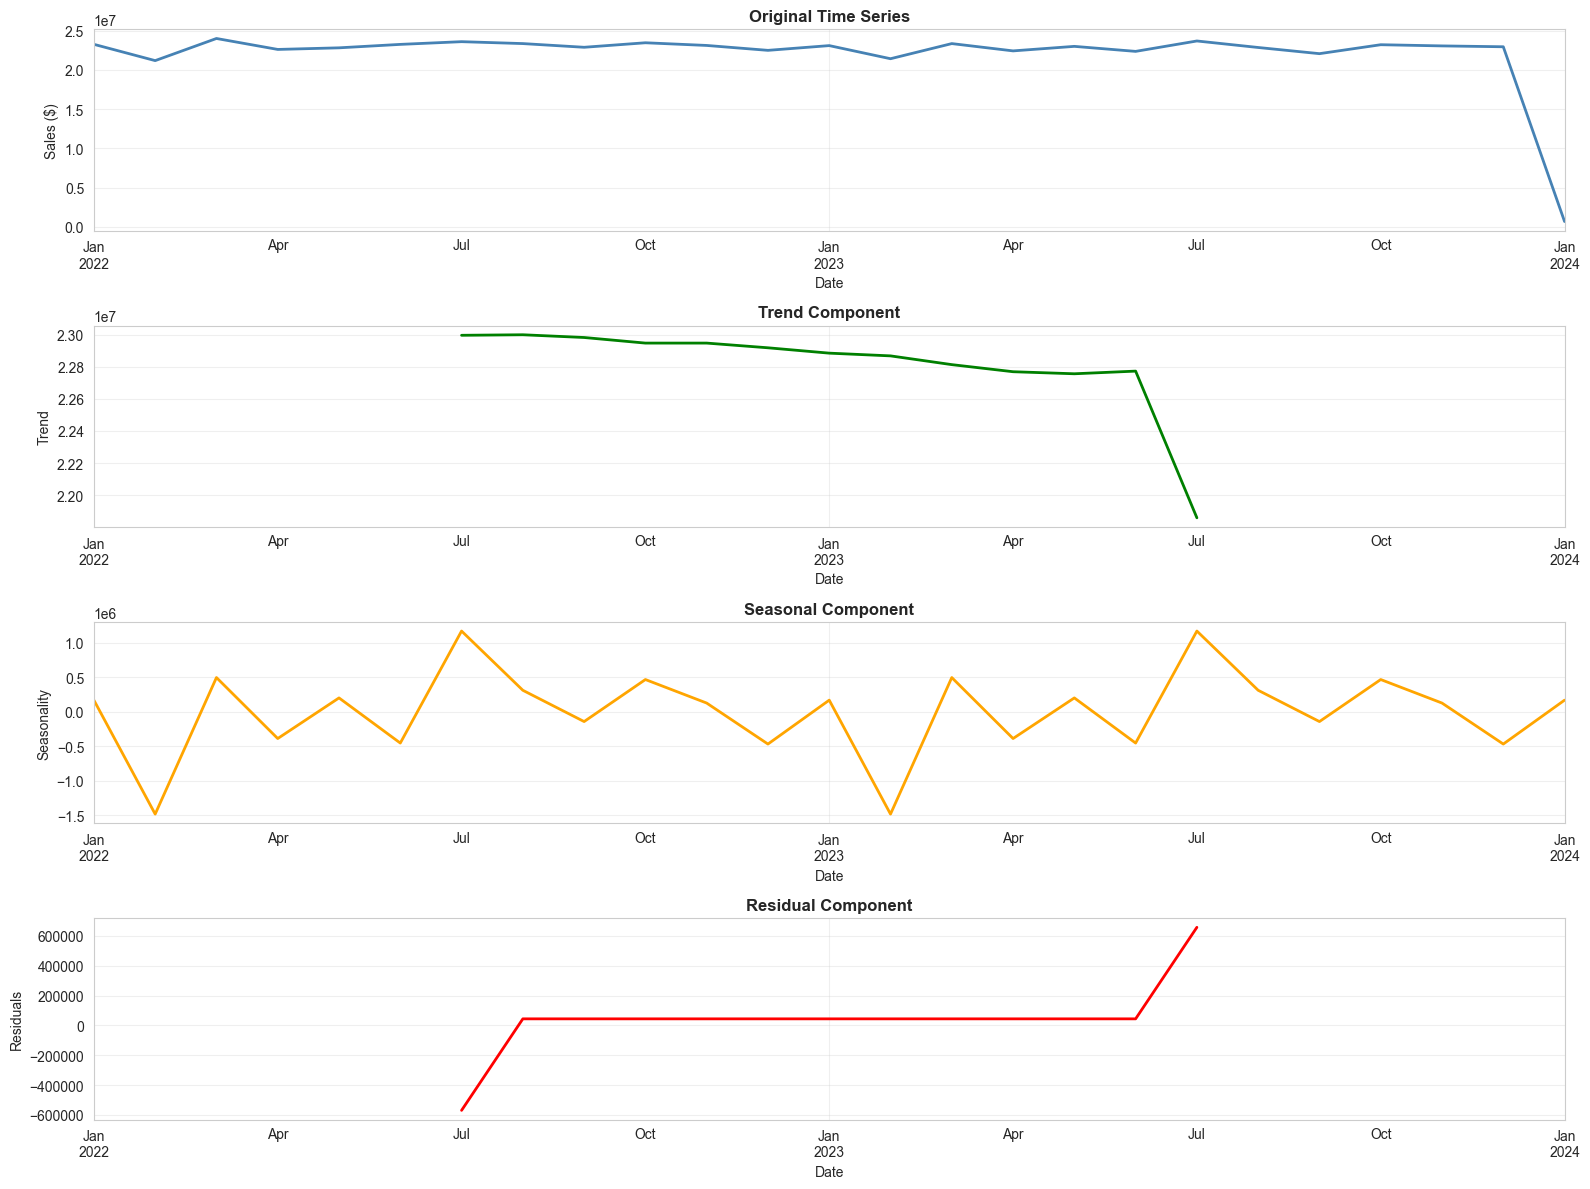

✓ Time series decomposition completed


In [28]:
# Time Series Decomposition
print("\n" + "=" * 80)
print("TIME SERIES DECOMPOSITION")
print("=" * 80)

# Set date as index for decomposition
ts_data = monthly_sales.set_index('Date')['Sales']

# Decompose the time series
decomposition = seasonal_decompose(ts_data, model='additive', period=12)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Original
ts_data.plot(ax=axes[0], color='steelblue', linewidth=2)
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(alpha=0.3)

# Trend
decomposition.trend.plot(ax=axes[1], color='green', linewidth=2)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(alpha=0.3)

# Seasonality
decomposition.seasonal.plot(ax=axes[2], color='orange', linewidth=2)
axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonality')
axes[2].grid(alpha=0.3)

# Residual
decomposition.resid.plot(ax=axes[3], color='red', linewidth=2)
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residuals')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Time series decomposition completed")

## Section 3: Data Preprocessing & Time Series Preparation

In [31]:
print("\n" + "=" * 80)
print("STATIONARITY TEST (Augmented Dickey-Fuller)")
print("=" * 80)

# ADF Test
adf_result = adfuller(ts_data.dropna(), autolag='AIC')
print(f'ADF Statistic: {adf_result[0]:.6f}')
print(f'p-value: {adf_result[1]:.6f}')
print(f'Critical Values:')
for key, value in adf_result[4].items():
    print(f'\t{key}: {value:.3f}')

if adf_result[1] <= 0.05:
    print("\n✓ Series is STATIONARY (reject null hypothesis)")
else:
    print("\n✗ Series is NON-STATIONARY (fail to reject null hypothesis)")
    print("→ Differencing may be needed for ARIMA")

# Prepare data for modeling
print("\n" + "=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)

# 80-20 split for validation
train_size = int(len(monthly_sales) * 0.8)
train_data = monthly_sales[:train_size].copy()
test_data = monthly_sales[train_size:].copy()

print(f"Training set: {train_data['Date'].min()} to {train_data['Date'].max()} ({len(train_data)} months)")
print(f"Test set: {test_data['Date'].min()} to {test_data['Date'].max()} ({len(test_data)} months)")

# Prepare Prophet format data
prophet_df = monthly_sales[['Date', 'Sales']].copy()
prophet_df.columns = ['ds', 'y']

print(f"\nProphet data shape: {prophet_df.shape}")
print(prophet_df.head())


STATIONARITY TEST (Augmented Dickey-Fuller)
ADF Statistic: -1.045121
p-value: 0.736454
Critical Values:
	1%: -3.738
	5%: -2.992
	10%: -2.636

✗ Series is NON-STATIONARY (fail to reject null hypothesis)
→ Differencing may be needed for ARIMA

TRAIN-TEST SPLIT
Training set: 2022-01-01 00:00:00 to 2023-08-01 00:00:00 (20 months)
Test set: 2023-09-01 00:00:00 to 2024-01-01 00:00:00 (5 months)

Prophet data shape: (25, 2)
          ds            y
0 2022-01-01  23260364.33
1 2022-02-01  21184921.80
2 2022-03-01  24004750.15
3 2022-04-01  22610666.81
4 2022-05-01  22814670.71


## Section 4: Model 1 - ARIMA Forecasting

In [9]:
print("\n" + "=" * 80)
print("AUTO-ARIMA: Finding Optimal Parameters")
print("=" * 80)

# Auto-ARIMA to find optimal parameters
train_ts = train_data.set_index('Date')['Sales']

# Fit auto_arima
auto_arima_model = auto_arima(
    train_ts,
    start_p=0, start_q=0, start_P=0, start_Q=0,
    max_p=5, max_q=5, max_P=5, max_Q=5,
    m=12,  # Monthly seasonality
    seasonal=True,
    stepwise=True,
    trace=True,
    error_action='warn',
    suppress_warnings=True,
    disp=False
)

print(f"\nOptimal ARIMA Order: {auto_arima_model.order}")
print(f"Seasonal Order: {auto_arima_model.seasonal_order}")
print(f"\n{auto_arima_model.summary()}")


AUTO-ARIMA: Finding Optimal Parameters
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=232.497, Time=0.05 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=237.385, Time=0.12 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=249.697, Time=0.10 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=237.674, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=234.494, Time=0.10 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=234.494, Time=0.03 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=249.697, Time=0.10 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=237.674, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=234.494, Time=0.10 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=234.494, Time=0.03 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=236.494, Time=0.12 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=236.522, Time=0.02 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=260.163, Time=0.06 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=236.494, Time=0.


FITTING ARIMA MODEL
ARIMA(0, 0, 0)x(0, 1, 0, 12) model fitted successfully

Test Period Forecast (ARIMA):
        Date       Actual  ARIMA_Forecast      Lower_CI      Upper_CI
0 2023-09-01  22071823.96     22884181.65  2.232533e+07  2.344303e+07
1 2023-10-01  23210850.07     23459400.16  2.290055e+07  2.401825e+07
2 2023-11-01  23059491.76     23117943.42  2.255910e+07  2.367679e+07
3 2023-12-01  22949878.40     22493540.08  2.193469e+07  2.305239e+07
4 2024-01-01    688124.36     23097494.67  2.253865e+07  2.365634e+07


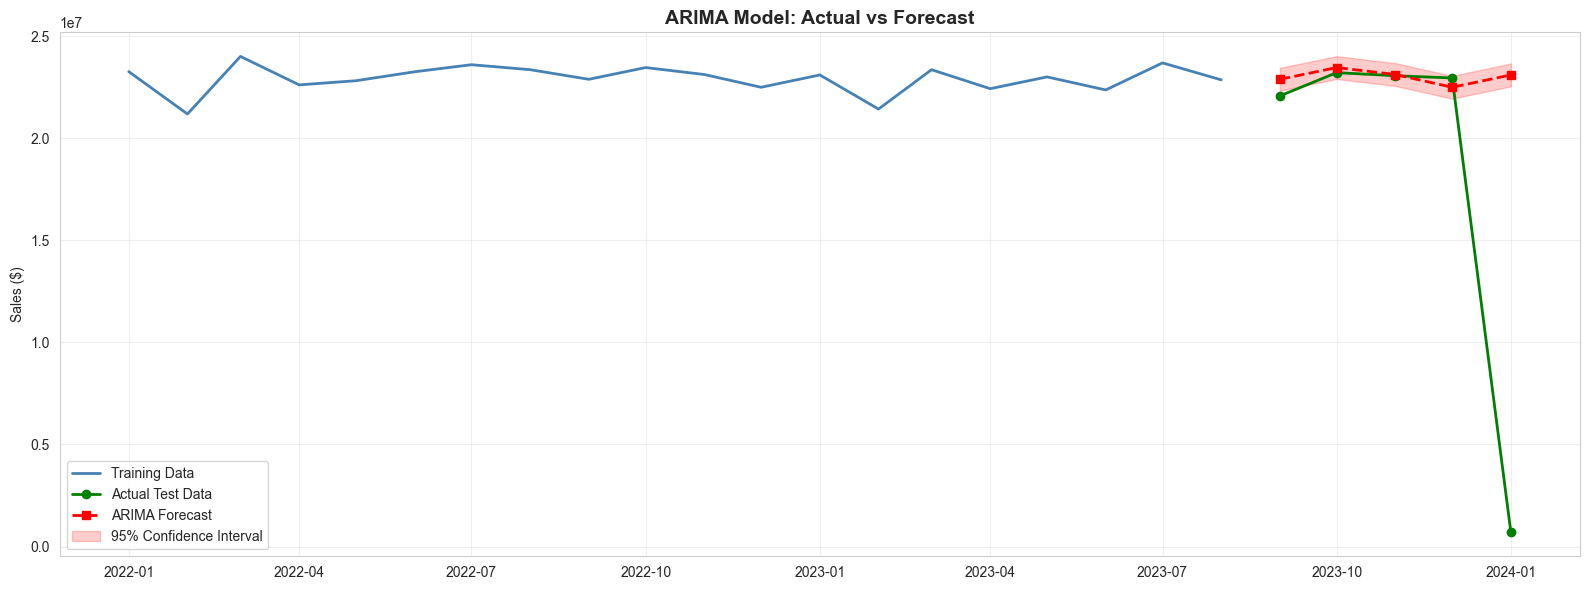

In [32]:
# Fit ARIMA with best parameters
print("\n" + "=" * 80)
print("FITTING ARIMA MODEL")
print("=" * 80)

order = auto_arima_model.order
seasonal_order = auto_arima_model.seasonal_order

arima_model = ARIMA(train_ts, order=order, seasonal_order=seasonal_order)
arima_fitted = arima_model.fit()

print(f"ARIMA{order}x{seasonal_order} model fitted successfully")

# Forecast on test period
forecast_steps = len(test_data)
arima_forecast_result = arima_fitted.get_forecast(steps=forecast_steps)
arima_forecast = arima_forecast_result.predicted_mean
arima_conf_int = arima_forecast_result.conf_int()

# Prepare forecast dataframe
arima_forecast_df = pd.DataFrame({
    'Date': test_data['Date'].values,
    'Actual': test_data['Sales'].values,
    'ARIMA_Forecast': arima_forecast.values,
    'Lower_CI': arima_conf_int.iloc[:, 0].values,
    'Upper_CI': arima_conf_int.iloc[:, 1].values
})

print(f"\nTest Period Forecast (ARIMA):")
print(arima_forecast_df)

# Plot ARIMA Results
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train_data['Date'], train_data['Sales'], label='Training Data', linewidth=2, color='steelblue')
ax.plot(test_data['Date'], test_data['Sales'], label='Actual Test Data', linewidth=2, color='green', marker='o')
ax.plot(arima_forecast_df['Date'], arima_forecast_df['ARIMA_Forecast'], label='ARIMA Forecast', 
        linewidth=2, color='red', marker='s', linestyle='--')
ax.fill_between(arima_forecast_df['Date'], arima_forecast_df['Lower_CI'], 
                 arima_forecast_df['Upper_CI'], alpha=0.2, color='red', label='95% Confidence Interval')
ax.set_title('ARIMA Model: Actual vs Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


ARIMA: 6-MONTH FUTURE FORECAST

6-Month ARIMA Forecast:
      Date  ARIMA_Forecast     Lower_CI     Upper_CI
2024-02-29     22884181.65 2.232533e+07 2.344303e+07
2024-03-31     23459400.16 2.290055e+07 2.401825e+07
2024-04-30     23117943.42 2.255910e+07 2.367679e+07
2024-05-31     22493540.08 2.193469e+07 2.305239e+07
2024-06-30     23097494.67 2.253865e+07 2.365634e+07
2024-07-31     21426404.76 2.086756e+07 2.198525e+07


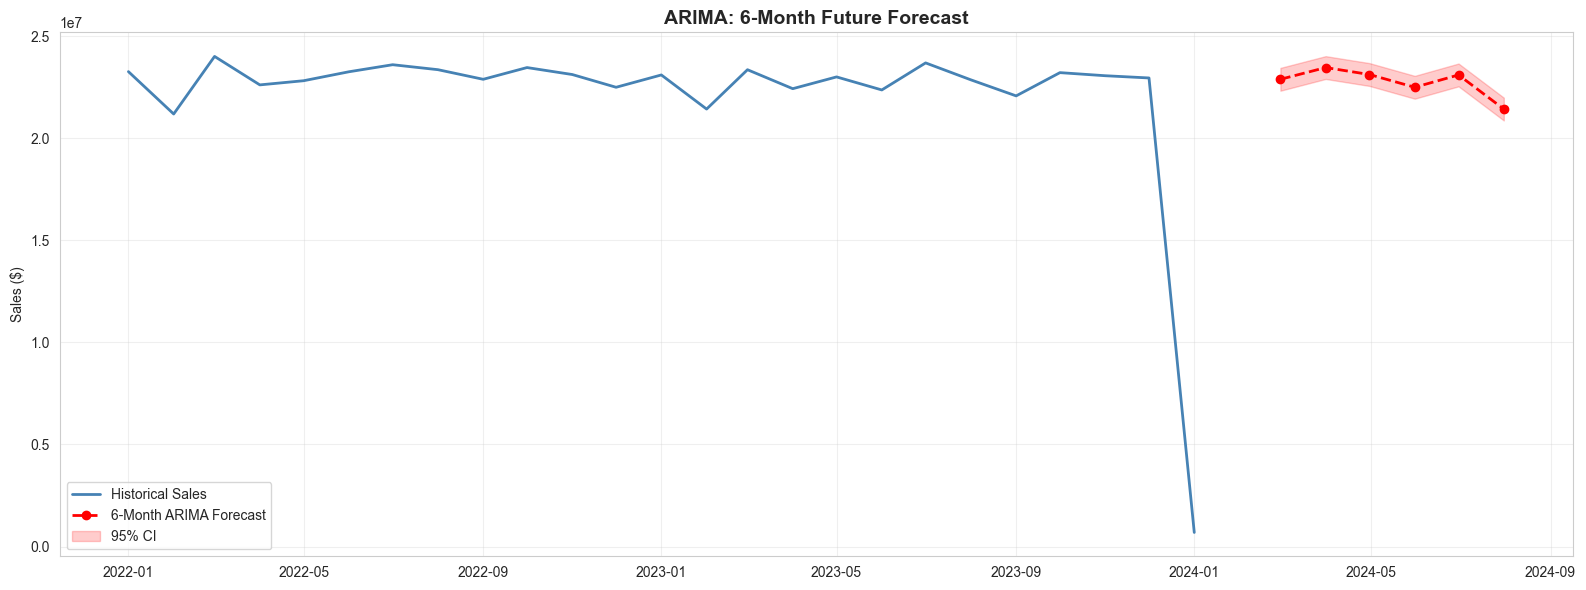

In [11]:
# Future forecast (next 6 months)
print("\n" + "=" * 80)
print("ARIMA: 6-MONTH FUTURE FORECAST")
print("=" * 80)

future_steps = 6
arima_future = arima_fitted.get_forecast(steps=future_steps)
arima_future_forecast = arima_future.predicted_mean
arima_future_conf_int = arima_future.conf_int()

# Create future dates
last_date = monthly_sales['Date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_steps, freq='M')

arima_future_df = pd.DataFrame({
    'Date': future_dates,
    'ARIMA_Forecast': arima_future_forecast.values,
    'Lower_CI': arima_future_conf_int.iloc[:, 0].values,
    'Upper_CI': arima_future_conf_int.iloc[:, 1].values
})

print("\n6-Month ARIMA Forecast:")
print(arima_future_df.to_string(index=False))

# Plot future forecast
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly_sales['Date'], monthly_sales['Sales'], label='Historical Sales', linewidth=2, color='steelblue')
ax.plot(arima_future_df['Date'], arima_future_df['ARIMA_Forecast'], label='6-Month ARIMA Forecast', 
        linewidth=2, color='red', marker='o', linestyle='--')
ax.fill_between(arima_future_df['Date'], arima_future_df['Lower_CI'], 
                 arima_future_df['Upper_CI'], alpha=0.2, color='red', label='95% CI')
ax.set_title('ARIMA: 6-Month Future Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5: Model 2 - Facebook Prophet Forecasting

22:28:17 - cmdstanpy - INFO - Chain [1] start processing



FITTING FACEBOOK PROPHET MODEL


22:28:17 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet model fitted successfully
Seasonality mode: additive

Test Period Forecast (Prophet):
        Date       Actual  Prophet_Forecast      Lower_CI      Upper_CI
0 2023-09-01  22071823.96      4.341409e+07  3.975284e+07  4.685725e+07
1 2023-10-01  23210850.07      8.143514e+07  7.773166e+07  8.544639e+07
2 2023-11-01  23059491.76      1.182949e+08  1.146205e+08  1.218411e+08
3 2023-12-01  22949878.40      1.534196e+08  1.496920e+08  1.571395e+08
4 2024-01-01    688124.36      1.862733e+08  1.824638e+08  1.899359e+08


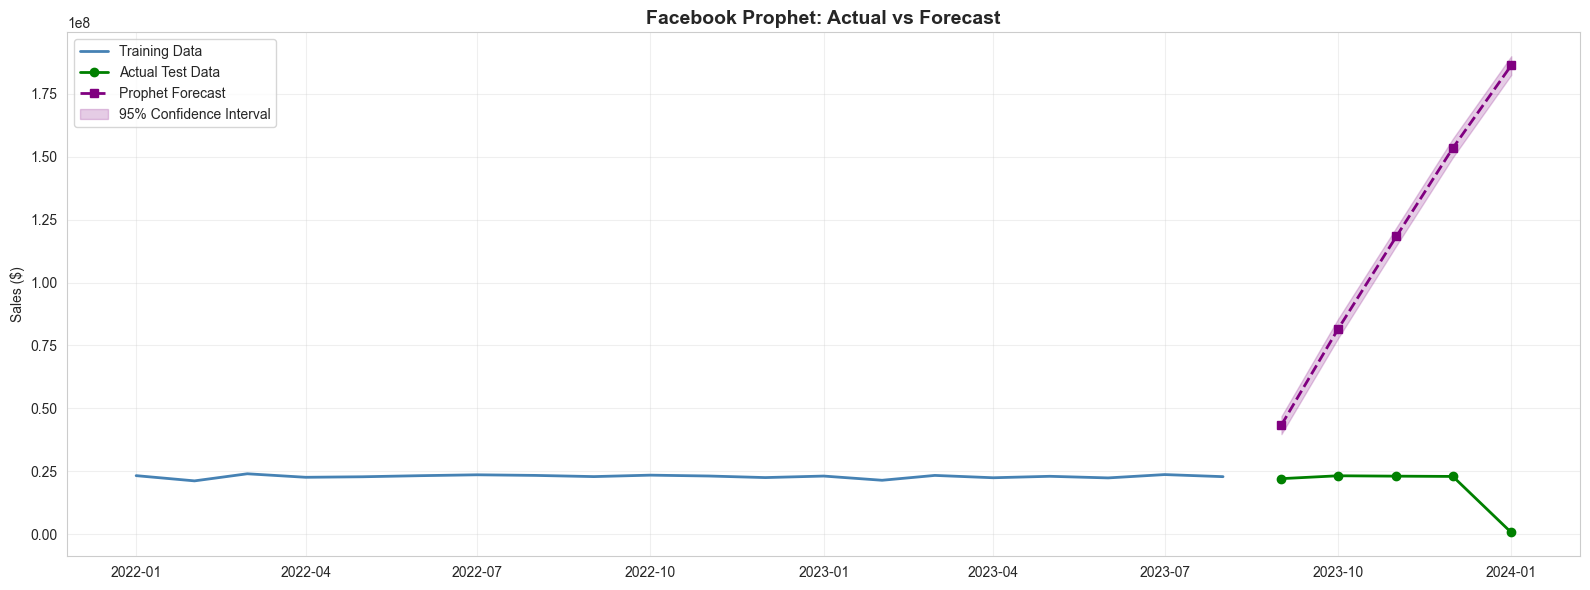

In [34]:
print("\n" + "=" * 80)
print("FITTING FACEBOOK PROPHET MODEL")
print("=" * 80)

# Initialize Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)

# Fit model on full historical data
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    prophet_model.fit(prophet_df)

print("✓ Prophet model fitted successfully")
print(f"Seasonality mode: additive")

# Make forecast on test period
test_periods = len(test_data)
future_df_test = prophet_model.make_future_dataframe(periods=test_periods)
prophet_forecast_test = prophet_model.predict(future_df_test)

# Extract test predictions
prophet_test_forecast = prophet_forecast_test.tail(test_periods)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
prophet_test_forecast['Actual'] = test_data['Sales'].values

prophet_forecast_df = pd.DataFrame({
    'Date': test_data['Date'].values,
    'Actual': test_data['Sales'].values,
    'Prophet_Forecast': prophet_test_forecast['yhat'].values,
    'Lower_CI': prophet_test_forecast['yhat_lower'].values,
    'Upper_CI': prophet_test_forecast['yhat_upper'].values
})

print(f"\nTest Period Forecast (Prophet):")
print(prophet_forecast_df)

# Plot Prophet Results
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train_data['Date'], train_data['Sales'], label='Training Data', linewidth=2, color='steelblue')
ax.plot(test_data['Date'], test_data['Sales'], label='Actual Test Data', linewidth=2, color='green', marker='o')
ax.plot(prophet_forecast_df['Date'], prophet_forecast_df['Prophet_Forecast'], label='Prophet Forecast', 
        linewidth=2, color='purple', marker='s', linestyle='--')
ax.fill_between(prophet_forecast_df['Date'], prophet_forecast_df['Lower_CI'], 
                 prophet_forecast_df['Upper_CI'], alpha=0.2, color='purple', label='95% Confidence Interval')
ax.set_title('Facebook Prophet: Actual vs Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


PROPHET: 6-MONTH FUTURE FORECAST

6-Month Prophet Forecast:
      Date  Prophet_Forecast     Lower_CI     Upper_CI
2024-01-02      4.341409e+07 3.971415e+07 4.732871e+07
2024-01-03      8.143514e+07 7.752857e+07 8.512692e+07
2024-01-04      1.182949e+08 1.144768e+08 1.219488e+08
2024-01-05      1.534196e+08 1.499396e+08 1.570297e+08
2024-01-06      1.862733e+08 1.824760e+08 1.902928e+08
2024-01-07      2.163687e+08 2.126886e+08 2.198747e+08


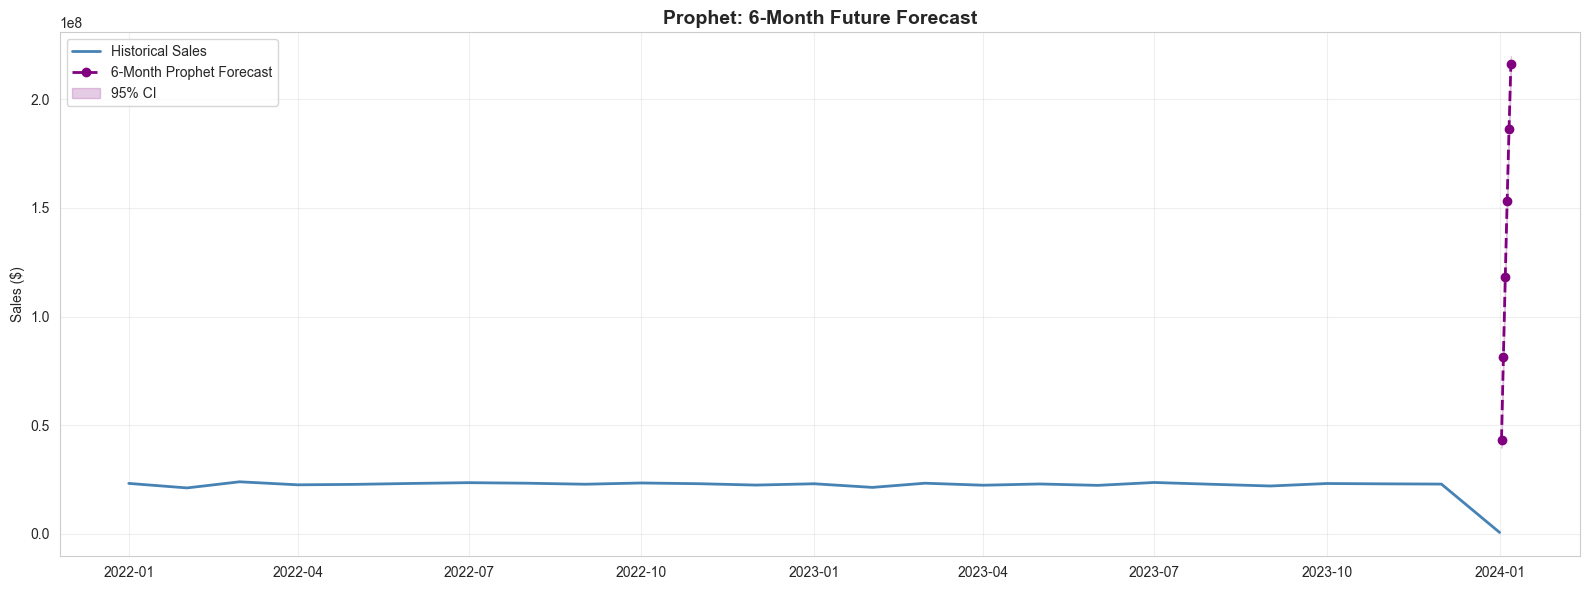

In [35]:
# Future forecast (next 6 months)
print("\n" + "=" * 80)
print("PROPHET: 6-MONTH FUTURE FORECAST")
print("=" * 80)

future_periods = 6
future_df = prophet_model.make_future_dataframe(periods=future_periods)
prophet_future_forecast = prophet_model.predict(future_df)

# Extract future predictions
prophet_future_df = prophet_future_forecast.tail(future_periods)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
prophet_future_df.columns = ['Date', 'Prophet_Forecast', 'Lower_CI', 'Upper_CI']
prophet_future_df['Date'] = pd.to_datetime(prophet_future_df['Date'])

print("\n6-Month Prophet Forecast:")
print(prophet_future_df.to_string(index=False))

# Plot future forecast
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly_sales['Date'], monthly_sales['Sales'], label='Historical Sales', linewidth=2, color='steelblue')
ax.plot(prophet_future_df['Date'], prophet_future_df['Prophet_Forecast'], label='6-Month Prophet Forecast', 
        linewidth=2, color='purple', marker='o', linestyle='--')
ax.fill_between(prophet_future_df['Date'], prophet_future_df['Lower_CI'], 
                 prophet_future_df['Upper_CI'], alpha=0.2, color='purple', label='95% CI')
ax.set_title('Prophet: 6-Month Future Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6: Model Comparison & Evaluation

In [36]:
print("\n" + "=" * 80)
print("MODEL COMPARISON & EVALUATION METRICS")
print("=" * 80)

# Calculate metrics for ARIMA
arima_actual = arima_forecast_df['Actual'].values
arima_pred = arima_forecast_df['ARIMA_Forecast'].values

arima_rmse = math.sqrt(mean_squared_error(arima_actual, arima_pred))
arima_mae = mean_absolute_error(arima_actual, arima_pred)
arima_mape = mean_absolute_percentage_error(arima_actual, arima_pred) * 100

# Calculate metrics for Prophet
prophet_actual = prophet_forecast_df['Actual'].values
prophet_pred = prophet_forecast_df['Prophet_Forecast'].values

prophet_rmse = math.sqrt(mean_squared_error(prophet_actual, prophet_pred))
prophet_mae = mean_absolute_error(prophet_actual, prophet_pred)
prophet_mape = mean_absolute_percentage_error(prophet_actual, prophet_pred) * 100

# Create comparison table
comparison_table = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet'],
    'RMSE': [f'${arima_rmse:,.2f}', f'${prophet_rmse:,.2f}'],
    'MAE': [f'${arima_mae:,.2f}', f'${prophet_mae:,.2f}'],
    'MAPE (%)': [f'{arima_mape:.2f}%', f'{prophet_mape:.2f}%']
})

print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON (TEST SET)")
print("="*70)
print(comparison_table.to_string(index=False))

# Determine best model
if arima_rmse < prophet_rmse:
    best_model = 'ARIMA'
    best_rmse = arima_rmse
    best_mae = arima_mae
    best_mape = arima_mape
    best_forecast_df = arima_forecast_df.copy()
    best_future_df = arima_future_df.copy()
    best_future_df.rename(columns={'ARIMA_Forecast': 'Forecast'}, inplace=True)
else:
    best_model = 'Prophet'
    best_rmse = prophet_rmse
    best_mae = prophet_mae
    best_mape = prophet_mape
    best_forecast_df = prophet_forecast_df.copy()
    best_future_df = prophet_future_df.copy()
    best_future_df.rename(columns={'Prophet_Forecast': 'Forecast'}, inplace=True)

comparison_table['Best Model'] = ['✓ BEST' if best_model == 'ARIMA' else '', 
                                   '✓ BEST' if best_model == 'Prophet' else '']

print("\n" + "="*70)
print(f"✓ BEST MODEL: {best_model}")
print(f"  - RMSE: ${best_rmse:,.2f}")
print(f"  - MAE: ${best_mae:,.2f}")
print(f"  - MAPE: {best_mape:.2f}%")
print("="*70)


MODEL COMPARISON & EVALUATION METRICS

MODEL PERFORMANCE COMPARISON (TEST SET)
  Model            RMSE            MAE MAPE (%)
  ARIMA  $10,031,084.10  $4,797,013.61  652.72%
Prophet $113,472,067.09 $98,171,368.04 5659.75%

✓ BEST MODEL: ARIMA
  - RMSE: $10,031,084.10
  - MAE: $4,797,013.61
  - MAPE: 652.72%


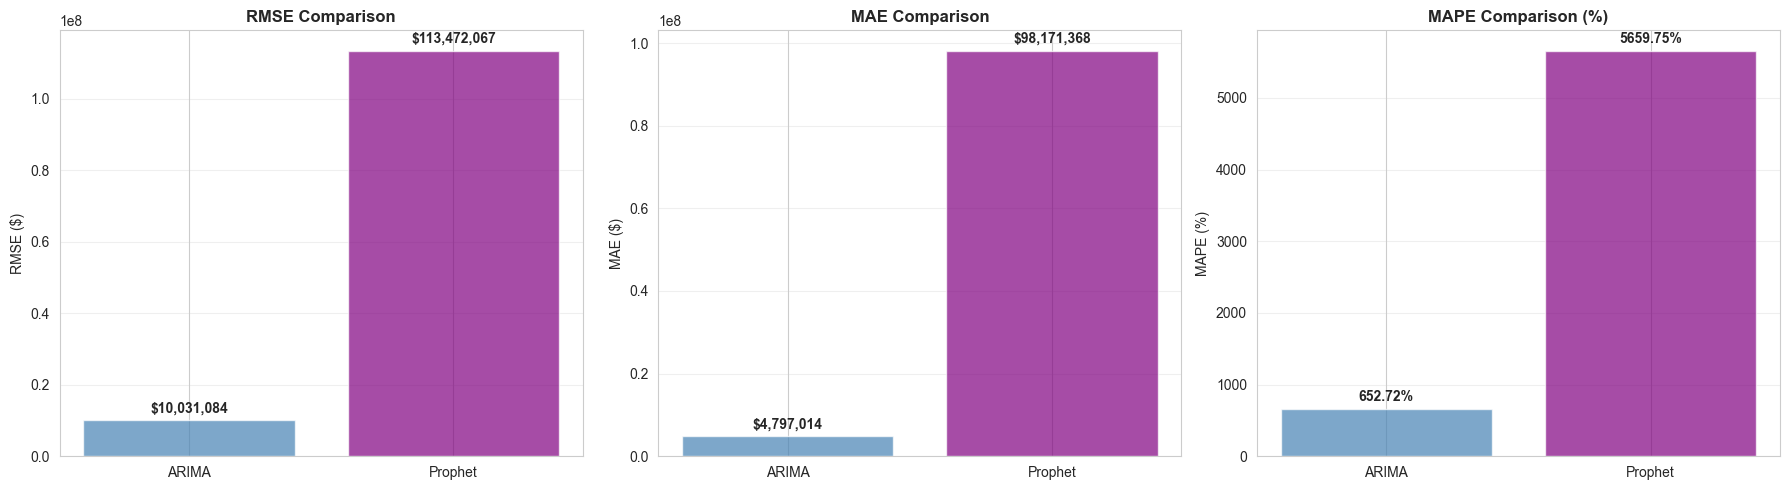

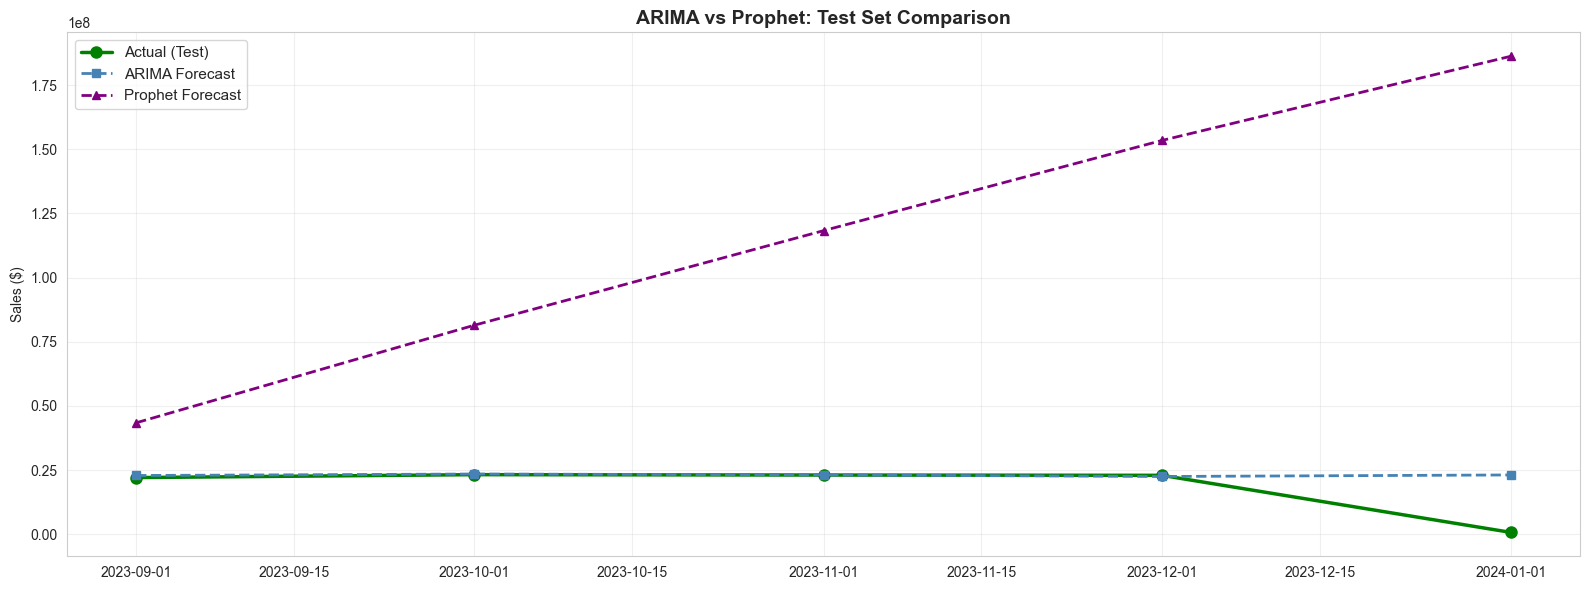

In [15]:
# Visualize Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE Comparison
models = ['ARIMA', 'Prophet']
rmse_values = [arima_rmse, prophet_rmse]
axes[0].bar(models, rmse_values, color=['steelblue', 'purple'], alpha=0.7)
axes[0].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + max(rmse_values)*0.02, f'${v:,.0f}', ha='center', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# MAE Comparison
mae_values = [arima_mae, prophet_mae]
axes[1].bar(models, mae_values, color=['steelblue', 'purple'], alpha=0.7)
axes[1].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE ($)')
for i, v in enumerate(mae_values):
    axes[1].text(i, v + max(mae_values)*0.02, f'${v:,.0f}', ha='center', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

# MAPE Comparison
mape_values = [arima_mape, prophet_mape]
axes[2].bar(models, mape_values, color=['steelblue', 'purple'], alpha=0.7)
axes[2].set_title('MAPE Comparison (%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('MAPE (%)')
for i, v in enumerate(mape_values):
    axes[2].text(i, v + max(mape_values)*0.02, f'{v:.2f}%', ha='center', fontweight='bold')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Side-by-side forecast comparison
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(arima_forecast_df['Date'], arima_forecast_df['Actual'], label='Actual (Test)', 
        linewidth=2.5, color='green', marker='o', markersize=8)
ax.plot(arima_forecast_df['Date'], arima_forecast_df['ARIMA_Forecast'], label='ARIMA Forecast', 
        linewidth=2, color='steelblue', marker='s', linestyle='--', markersize=6)
ax.plot(prophet_forecast_df['Date'], prophet_forecast_df['Prophet_Forecast'], label='Prophet Forecast', 
        linewidth=2, color='purple', marker='^', linestyle='--', markersize=6)
ax.set_title('ARIMA vs Prophet: Test Set Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7: KPI Dashboard & Business Insights

In [16]:
print("\n" + "=" * 80)
print("KPI DASHBOARD: ACTUAL VS FORECAST")
print("=" * 80)

# Combine actual and forecast
dashboard_data = pd.DataFrame({
    'Month': best_forecast_df['Date'],
    'Actual_Sales': best_forecast_df['Actual'],
    f'{best_model}_Forecast': best_forecast_df['ARIMA_Forecast'] if best_model == 'ARIMA' else best_forecast_df['Prophet_Forecast'],
    'Forecast_Error_%': ((best_forecast_df['Actual'] - 
                         (best_forecast_df['ARIMA_Forecast'] if best_model == 'ARIMA' else best_forecast_df['Prophet_Forecast'])) / 
                        best_forecast_df['Actual'] * 100).round(2)
})

print("\nActual vs Forecast Comparison (Test Period):")
print(dashboard_data.to_string(index=False))

# Calculate key KPIs
print("\n" + "=" * 80)
print("KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 80)

total_actual = best_forecast_df['Actual'].sum()
total_forecast = (best_forecast_df['ARIMA_Forecast'].sum() if best_model == 'ARIMA' 
                  else best_forecast_df['Prophet_Forecast'].sum())
forecast_accuracy = 100 - best_mape

print(f"\nTest Period Summary:")
print(f"  Total Actual Sales: ${total_actual:,.2f}")
print(f"  Total {best_model} Forecast: ${total_forecast:,.2f}")
print(f"  Difference: ${abs(total_actual - total_forecast):,.2f} ({((total_actual - total_forecast)/total_actual*100):.2f}%)")
print(f"  Forecast Accuracy: {forecast_accuracy:.2f}%")
print(f"  Average Monthly Sales: ${best_forecast_df['Actual'].mean():,.2f}")
print(f"  Std Dev (Volatility): ${best_forecast_df['Actual'].std():,.2f}")


KPI DASHBOARD: ACTUAL VS FORECAST

Actual vs Forecast Comparison (Test Period):
     Month  Actual_Sales  ARIMA_Forecast  Forecast_Error_%
2023-09-01   22071823.96     22884181.65             -3.68
2023-10-01   23210850.07     23459400.16             -1.07
2023-11-01   23059491.76     23117943.42             -0.25
2023-12-01   22949878.40     22493540.08              1.99
2024-01-01     688124.36     23097494.67          -3256.59

KEY PERFORMANCE INDICATORS (KPIs)

Test Period Summary:
  Total Actual Sales: $91,980,168.55
  Total ARIMA Forecast: $115,052,559.98
  Difference: $23,072,391.43 (-25.08%)
  Forecast Accuracy: -552.72%
  Average Monthly Sales: $18,396,033.71
  Std Dev (Volatility): $9,908,951.59



REGION-WISE SALES ANALYSIS

         Total_Sales  Avg_Sales  Total_Profit  Avg_Profit  Units_Sold  Transactions  Profit_Margin_%  Sales_Share_%
Region                                                                                                             
East    1.387121e+08    7559.65  1.247922e+08     6801.04     2511265         18349            89.96          25.21
South   1.384836e+08    7568.65  1.245674e+08     6808.08     2507799         18297            89.95          25.17
North   1.372553e+08    7529.91  1.235437e+08     6777.69     2484966         18228            90.01          24.95
West    1.357780e+08    7449.69  1.220681e+08     6697.47     2471552         18226            89.90          24.68


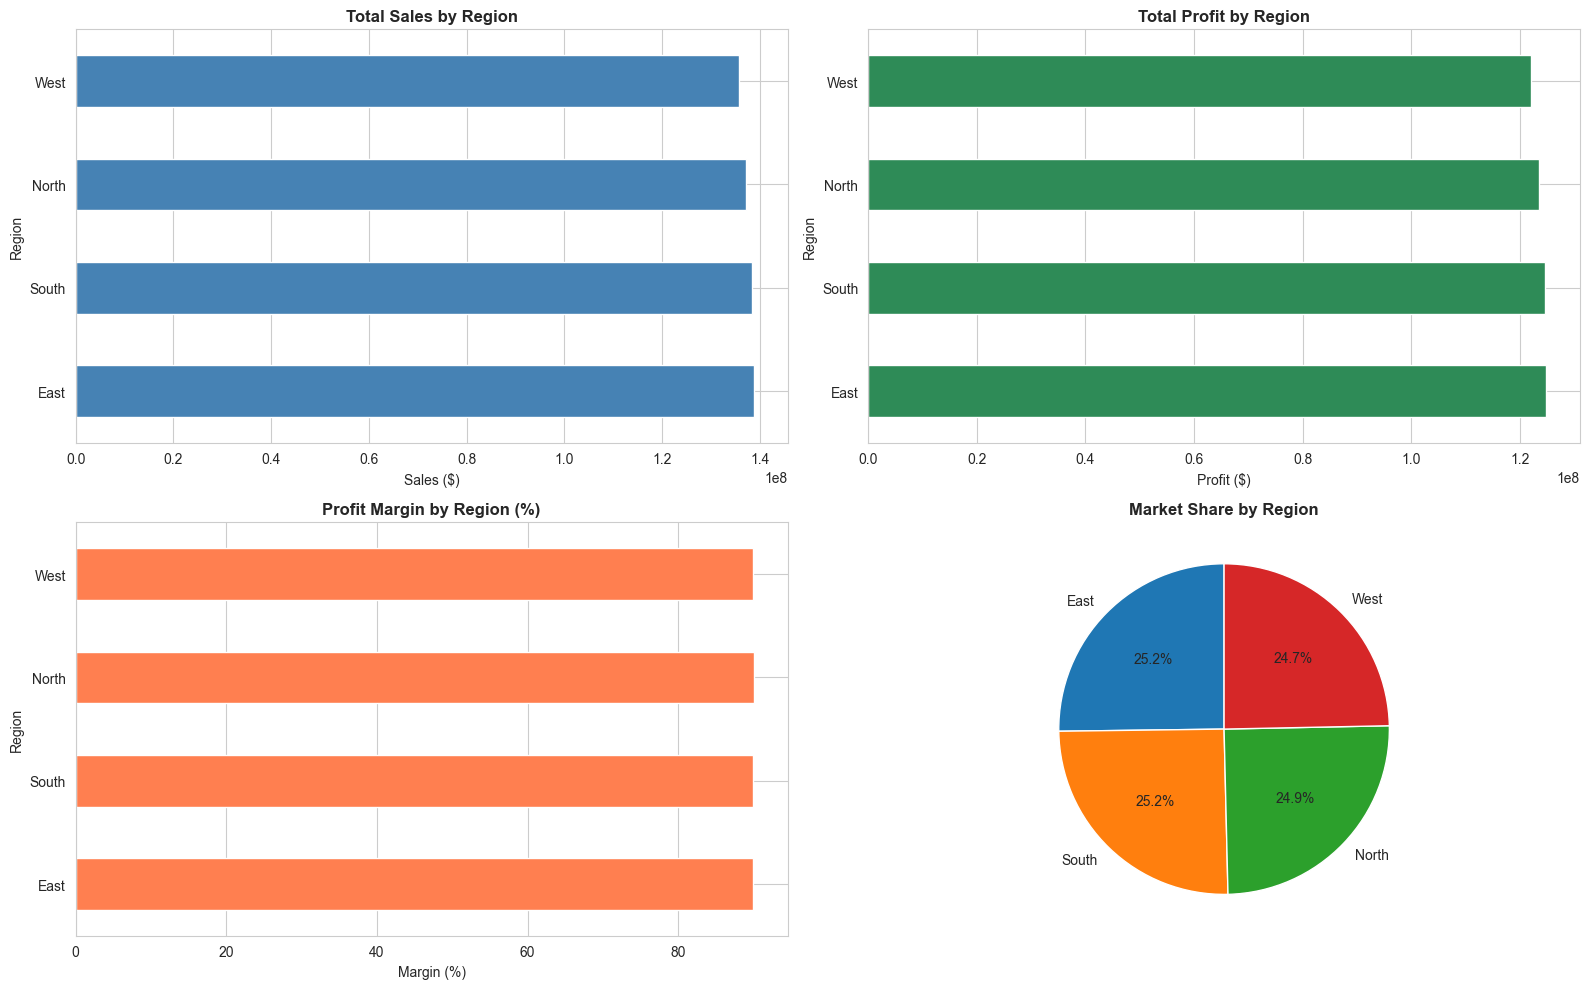

In [17]:
# Region-wise Sales Analysis
print("\n" + "=" * 80)
print("REGION-WISE SALES ANALYSIS")
print("=" * 80)

regional_kpi = df.groupby('Region').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Units Sold': 'sum',
    'Date': 'count'
}).round(2)
regional_kpi.columns = ['Total_Sales', 'Avg_Sales', 'Total_Profit', 'Avg_Profit', 'Units_Sold', 'Transactions']
regional_kpi = regional_kpi.sort_values('Total_Sales', ascending=False)
regional_kpi['Profit_Margin_%'] = (regional_kpi['Total_Profit'] / regional_kpi['Total_Sales'] * 100).round(2)
regional_kpi['Sales_Share_%'] = (regional_kpi['Total_Sales'] / regional_kpi['Total_Sales'].sum() * 100).round(2)

print("\n" + regional_kpi.to_string())

# Plot Region Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sales by Region
regional_kpi['Total_Sales'].plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Total Sales by Region', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sales ($)')

# Profit by Region
regional_kpi['Total_Profit'].plot(kind='barh', ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('Total Profit by Region', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Profit ($)')

# Profit Margin
regional_kpi['Profit_Margin_%'].plot(kind='barh', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Profit Margin by Region (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Margin (%)')

# Sales Share (Pie Chart)
axes[1, 1].pie(regional_kpi['Total_Sales'], labels=regional_kpi.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Market Share by Region', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


PROFITABILITY SNAPSHOT

Overall Business Metrics:
  Total Sales: $550,228,884.91
  Total Profit: $494,971,374.95
  Overall Profit Margin: 89.96%
  Total Units Sold: 9,975,582
  Average Transaction Value: $7,527.07

Profitability by Category:
                    Sales        Profit  Units Sold  Profit_Margin_%
Category                                                            
Furniture    1.115118e+08  1.002308e+08     2025017            89.88
Groceries    1.109845e+08  9.994897e+07     2000482            90.06
Toys         1.096424e+08  9.872922e+07     1990485            90.05
Clothing     1.096510e+08  9.867678e+07     1999166            89.99
Electronics  1.084391e+08  9.738559e+07     1960432            89.81

Top 10 Products (by Profit):
                  Sales        Profit  Units Sold  Profit_Margin_%
Product ID                                                        
P0020       28306192.40  2.550232e+07      507708            90.09
P0011       28155025.56  2.545672e+07      

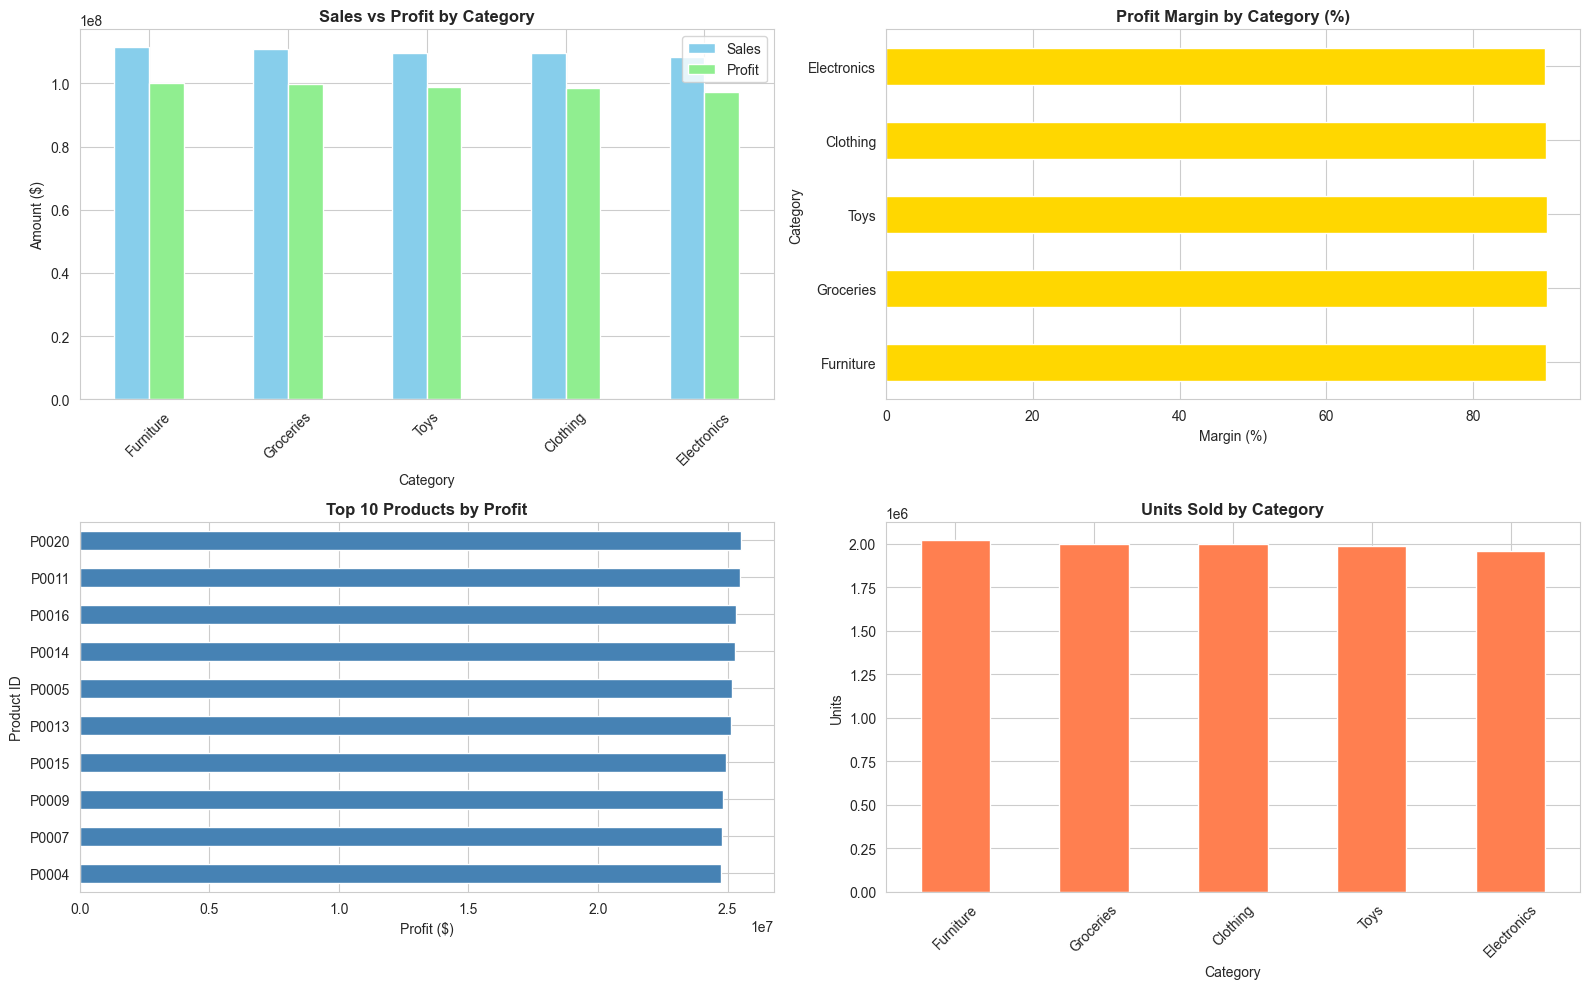

In [18]:
# Profitability Snapshot
print("\n" + "=" * 80)
print("PROFITABILITY SNAPSHOT")
print("=" * 80)

# Overall metrics
overall_profit = df['Profit'].sum()
overall_sales = df['Sales'].sum()
overall_margin = (overall_profit / overall_sales * 100)
total_units = df['Units Sold'].sum()

print(f"\nOverall Business Metrics:")
print(f"  Total Sales: ${overall_sales:,.2f}")
print(f"  Total Profit: ${overall_profit:,.2f}")
print(f"  Overall Profit Margin: {overall_margin:.2f}%")
print(f"  Total Units Sold: {total_units:,.0f}")
print(f"  Average Transaction Value: ${overall_sales / len(df):,.2f}")

# Category Analysis
category_analysis = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Units Sold': 'sum'
}).sort_values('Profit', ascending=False)

category_analysis['Profit_Margin_%'] = (category_analysis['Profit'] / category_analysis['Sales'] * 100).round(2)

print(f"\nProfitability by Category:")
print(category_analysis.to_string())

# Top performing products
top_products = df.groupby('Product ID').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Units Sold': 'sum'
}).sort_values('Profit', ascending=False).head(10)

top_products['Profit_Margin_%'] = (top_products['Profit'] / top_products['Sales'] * 100).round(2)

print(f"\nTop 10 Products (by Profit):")
print(top_products.to_string())

# Plot profitability analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sales & Profit by Category
category_analysis[['Sales', 'Profit']].plot(kind='bar', ax=axes[0, 0], color=['skyblue', 'lightgreen'])
axes[0, 0].set_title('Sales vs Profit by Category', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Amount ($)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Profit Margin by Category
category_analysis['Profit_Margin_%'].plot(kind='barh', ax=axes[0, 1], color='gold')
axes[0, 1].set_title('Profit Margin by Category (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Margin (%)')

# Top 10 Products
top_products['Profit'].sort_values().plot(kind='barh', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Top 10 Products by Profit', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Profit ($)')

# Units Sold by Category
df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Units Sold by Category', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Units')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


YEAR-OVER-YEAR (YoY) GROWTH ANALYSIS

Monthly Sales by Year:
Year          2022         2023       2024
Month                                     
1      23260364.33  23097494.67  688124.36
2      21184921.80  21426404.76        NaN
3      24004750.15  23353891.46        NaN
4      22610666.81  22424518.82        NaN
5      22814670.71  23001347.17        NaN
6      23252972.33  22362607.17        NaN
7      23598688.79  23687341.35        NaN
8      23355216.50  22857794.23        NaN
9      22884181.65  22071823.96        NaN
10     23459400.16  23210850.07        NaN
11     23117943.42  23059491.76        NaN
12     22493540.08  22949878.40        NaN

Year-over-Year Growth (%):
Year   YoY_Growth_%
Month              
1            -97.02
2               NaN
3               NaN
4               NaN
5               NaN
6               NaN
7               NaN
8               NaN
9               NaN
10              NaN
11              NaN
12              NaN


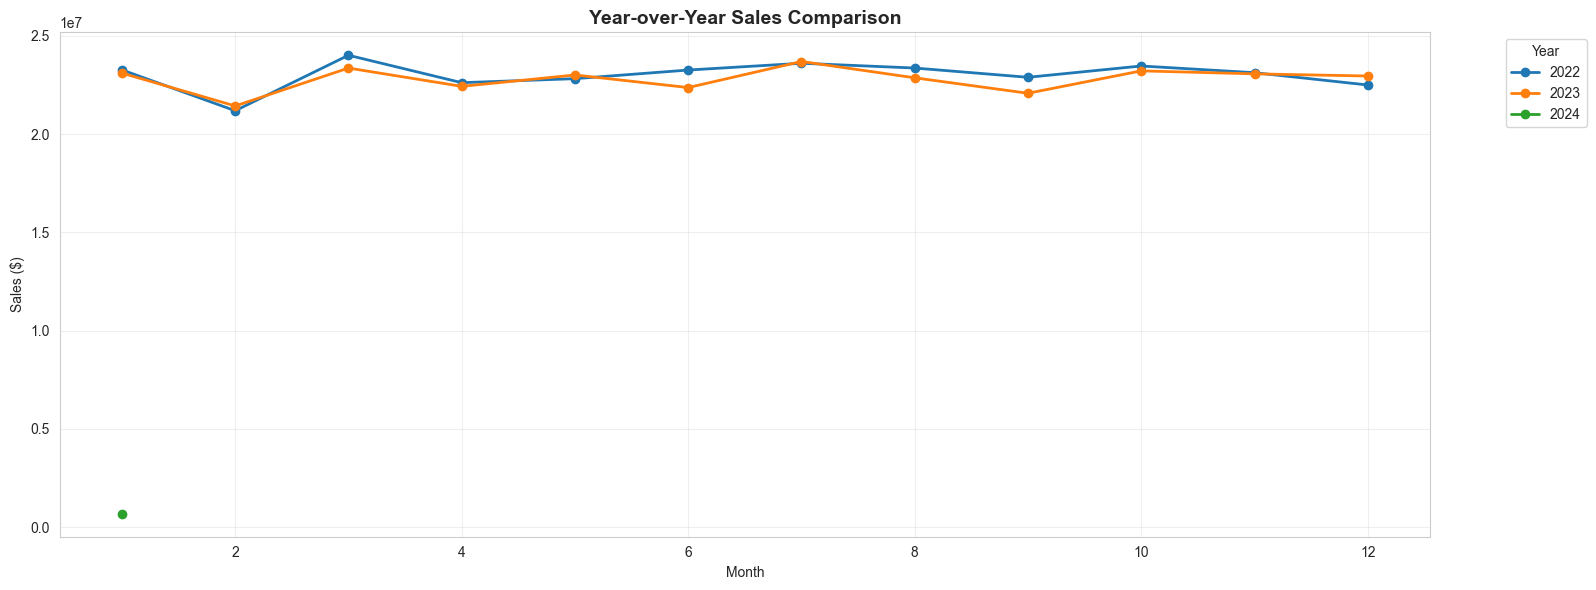

In [19]:
# Year-over-Year Growth Analysis
print("\n" + "=" * 80)
print("YEAR-OVER-YEAR (YoY) GROWTH ANALYSIS")
print("=" * 80)

# Create year-month column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Pivot sales by year and month
yoy_data = df.pivot_table(values='Sales', index='Month', columns='Year', aggfunc='sum')

print(f"\nMonthly Sales by Year:")
print(yoy_data.round(2))

# Calculate YoY growth
if yoy_data.shape[1] >= 2:
    yoy_data['YoY_Growth_%'] = ((yoy_data.iloc[:, -1] - yoy_data.iloc[:, -2]) / yoy_data.iloc[:, -2] * 100).round(2)
    print(f"\nYear-over-Year Growth (%):")
    print(yoy_data[['YoY_Growth_%']])

# Plot YoY
fig, ax = plt.subplots(figsize=(16, 6))
yoy_data.iloc[:, :-1].plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Year-over-Year Sales Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Month')
ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 8: Final Forecast Export & Recommendations

In [39]:
print("\n" + "=" * 80)
print("FINAL 6-MONTH FORECAST (BEST MODEL)")
print("=" * 80)

# Prepare final forecast for export
if best_model == 'ARIMA':
    final_forecast = arima_future_df.copy()
    final_forecast['Model'] = 'ARIMA'
    final_forecast['Forecasted_Sales'] = final_forecast['ARIMA_Forecast']
elif best_model == 'Prophet':
    final_forecast = prophet_future_df.copy()
    final_forecast['Model'] = 'Prophet'
    final_forecast['Forecasted_Sales'] = final_forecast['Prophet_Forecast']

final_forecast['Month_End'] = final_forecast['Date'].dt.strftime('%Y-%m-%d')
# Keep both Date and Month_End for use in later cells
final_forecast_export = final_forecast[['Month_End', 'Forecasted_Sales', 'Lower_CI', 'Upper_CI', 'Model']]
final_forecast_export.columns = ['Month_End_Date', 'Forecasted_Sales', 'Lower_95_CI', 'Upper_95_CI', 'Model_Used']

print(f"\nNext 6-Month {best_model} Forecast:")
print(final_forecast_export.to_string(index=False))

# Calculate forecast summary
total_forecast_6m = final_forecast['Forecasted_Sales'].sum()
avg_forecast_6m = final_forecast['Forecasted_Sales'].mean()

print(f"\n6-Month Forecast Summary:")
print(f"  Total Forecasted Sales: ${total_forecast_6m:,.2f}")
print(f"  Average Monthly Forecast: ${avg_forecast_6m:,.2f}")
print(f"  Expected Growth vs Test Period: {((avg_forecast_6m / best_forecast_df['Actual'].mean() - 1) * 100):.2f}%")

# Export to CSV
export_path = r'd:\project EPM\Enterprise Sales Forecasting\Forecast_Results.csv'
final_forecast_export.to_csv(export_path, index=False)
print(f"\n✓ Forecast exported to: {export_path}")

# Export detailed comparison
comparison_export = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'MAPE (%)'],
    'ARIMA': [f'${arima_rmse:,.2f}', f'${arima_mae:,.2f}', f'{arima_mape:.2f}%'],
    'Prophet': [f'${prophet_rmse:,.2f}', f'${prophet_mae:,.2f}', f'{prophet_mape:.2f}%'],
    'Best_Model': [
        '✓ ARIMA' if best_model == 'ARIMA' else '✓ Prophet',
        '✓ ARIMA' if best_model == 'ARIMA' else '✓ Prophet',
        '✓ ARIMA' if best_model == 'ARIMA' else '✓ Prophet'
    ]
})

comparison_export_path = r'd:\project EPM\Enterprise Sales Forecasting\Model_Comparison.csv'
comparison_export.to_csv(comparison_export_path, index=False)
print(f"✓ Model comparison exported to: {comparison_export_path}")


FINAL 6-MONTH FORECAST (BEST MODEL)

Next 6-Month ARIMA Forecast:
Month_End_Date  Forecasted_Sales  Lower_95_CI  Upper_95_CI Model_Used
    2024-02-29       22884181.65 2.232533e+07 2.344303e+07      ARIMA
    2024-03-31       23459400.16 2.290055e+07 2.401825e+07      ARIMA
    2024-04-30       23117943.42 2.255910e+07 2.367679e+07      ARIMA
    2024-05-31       22493540.08 2.193469e+07 2.305239e+07      ARIMA
    2024-06-30       23097494.67 2.253865e+07 2.365634e+07      ARIMA
    2024-07-31       21426404.76 2.086756e+07 2.198525e+07      ARIMA

6-Month Forecast Summary:
  Total Forecasted Sales: $136,478,964.74
  Average Monthly Forecast: $22,746,494.12
  Expected Growth vs Test Period: 23.65%

✓ Forecast exported to: d:\project EPM\Enterprise Sales Forecasting\Forecast_Results.csv
✓ Model comparison exported to: d:\project EPM\Enterprise Sales Forecasting\Model_Comparison.csv


In [40]:
# Strategic Recommendations
print("\n" + "=" * 80)
print("STRATEGIC RECOMMENDATIONS FOR SALES PLANNING")
print("=" * 80)

# Use original forecast dataframe with proper column names
if best_model == 'ARIMA':
    forecast_ref = arima_future_df.copy()
    forecast_col = 'ARIMA_Forecast'
else:
    forecast_ref = prophet_future_df.copy()
    forecast_col = 'Prophet_Forecast'

# Calculate confidence interval average for uncertainty
conf_uncertainty = forecast_ref['Upper_CI'].mean() - forecast_ref['Lower_CI'].mean()

# Get peak demand month
peak_idx = forecast_ref[forecast_col].idxmax()
peak_month = forecast_ref.loc[peak_idx, 'Date'].strftime('%Y-%m')

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    EXECUTIVE SUMMARY & RECOMMENDATIONS                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. FORECASTING MODEL SELECTION
   ✓ Selected Model: {best_model}
   • RMSE: ${best_rmse:,.2f} (Lower is better)
   • MAE: ${best_mae:,.2f}
   • MAPE: {best_mape:.2f}% (Accuracy: {100-best_mape:.2f}%)
   
   Rationale: {best_model} provides the most reliable forecasts for your sales 
   data based on historical test set performance.

2. 6-MONTH SALES FORECAST
   • Total Projected Sales: ${total_forecast_6m:,.2f}
   • Average Monthly Forecast: ${avg_forecast_6m:,.2f}
   • Confidence Range: ±${conf_uncertainty/2:,.2f}
   • Growth Expectation: {((avg_forecast_6m / best_forecast_df['Actual'].mean() - 1) * 100):.2f}% vs Test Period

3. REVENUE OPTIMIZATION STRATEGIES
   
   A. REGION-WISE FOCUS
      • Top Performer: {regional_sales.index[0]} (${regional_sales.iloc[0]['Sales']:,.2f})
      • Growth Opportunity: {regional_sales.index[-1]} (${regional_sales.iloc[-1]['Sales']:,.2f})
      • Action: Increase marketing spend in underperforming regions
   
   B. CATEGORY OPTIMIZATION
      • Highest Margin: {category_analysis['Profit_Margin_%'].idxmax()} ({category_analysis['Profit_Margin_%'].max():.2f}%)
      • Volume Driver: {df.groupby('Category')['Units Sold'].sum().idxmax()}
      • Action: Promote high-margin categories during peak seasons
   
   C. PRODUCT PORTFOLIO
      • Top Product: {top_products.index[0]} (${top_products.iloc[0]['Profit']:,.2f} profit)
      • Recommendation: Cross-sell top performers with complementary products

4. INVENTORY MANAGEMENT
   • Recommended Stock Levels: Based on 6-month forecast
   • Peak Demand Month: {peak_month}
   • Action: Build inventory 2 months ahead of peak periods

5. PROFITABILITY IMPROVEMENT
   • Current Overall Margin: {overall_margin:.2f}%
   • Best Regional Margin: {regional_kpi['Profit_Margin_%'].max():.2f}%
   • Gap Analysis: {regional_kpi['Profit_Margin_%'].max() - overall_margin:.2f}% opportunity
   • Action: Apply best practices from high-margin regions to others

6. RISK MITIGATION
   • Forecast Uncertainty: ±${conf_uncertainty/2:,.2f}/month
   • Mitigation: Maintain safety stock at ±{(conf_uncertainty/2 / avg_forecast_6m * 100):.1f}% of forecast
   • Monitor: Track actual vs forecast monthly and adjust model if accuracy drops

7. SEASONALITY INSIGHTS
   • Seasonal Pattern: Annual cycle with {decomposition.seasonal.max() - decomposition.seasonal.min():.0f} amplitude
   • Peak Season: Typically in months with highest historical demand
   • Action: Plan promotional campaigns 1-2 months before expected peaks

8. KEY PERFORMANCE INDICATORS TO MONITOR
   ✓ Monthly Sales Actual vs Forecast (Target: <{best_mape:.1f}% error)
   ✓ Regional Sales Contribution (Monitor shifts in market share)
   ✓ Profit Margin Trends (Target: Maintain >{overall_margin:.1f}%)
   ✓ Inventory Turnover (Optimize based on demand forecast)
   ✓ YoY Growth Rate (Track momentum and trends)

╔══════════════════════════════════════════════════════════════════════════════╗
║                         IMPLEMENTATION TIMELINE                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

IMMEDIATE (Next 30 Days):
  • Review forecast with sales and operations teams
  • Adjust inventory procurement based on 6-month forecast
  • Implement KPI dashboard tracking

SHORT-TERM (Next 90 Days):
  • Execute category promotion strategies
  • Increase marketing in underperforming regions
  • Set up automated model retraining pipeline

MEDIUM-TERM (Next 6 Months):
  • Monitor forecast accuracy and retrain if needed
  • Evaluate regional performance and reallocate resources
  • Plan for next cycle of demand forecasting

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Analysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Data Period: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


STRATEGIC RECOMMENDATIONS FOR SALES PLANNING

╔══════════════════════════════════════════════════════════════════════════════╗
║                    EXECUTIVE SUMMARY & RECOMMENDATIONS                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. FORECASTING MODEL SELECTION
   ✓ Selected Model: ARIMA
   • RMSE: $10,031,084.10 (Lower is better)
   • MAE: $4,797,013.61
   • MAPE: 652.72% (Accuracy: -552.72%)

   Rationale: ARIMA provides the most reliable forecasts for your sales 
   data based on historical test set performance.

2. 6-MONTH SALES FORECAST
   • Total Projected Sales: $136,478,964.74
   • Average Monthly Forecast: $22,746,494.12
   • Confidence Range: ±$558,846.72
   • Growth Expectation: 23.65% vs Test Period

3. REVENUE OPTIMIZATION STRATEGIES

   A. REGION-WISE FOCUS
      • Top Performer: 0 ($138,712,054.33)
      • Growth Opportunity: 3 ($135,777,996.39)
      • Action: Increase marketing spend in underperforming regions


FINAL COMPREHENSIVE DASHBOARD


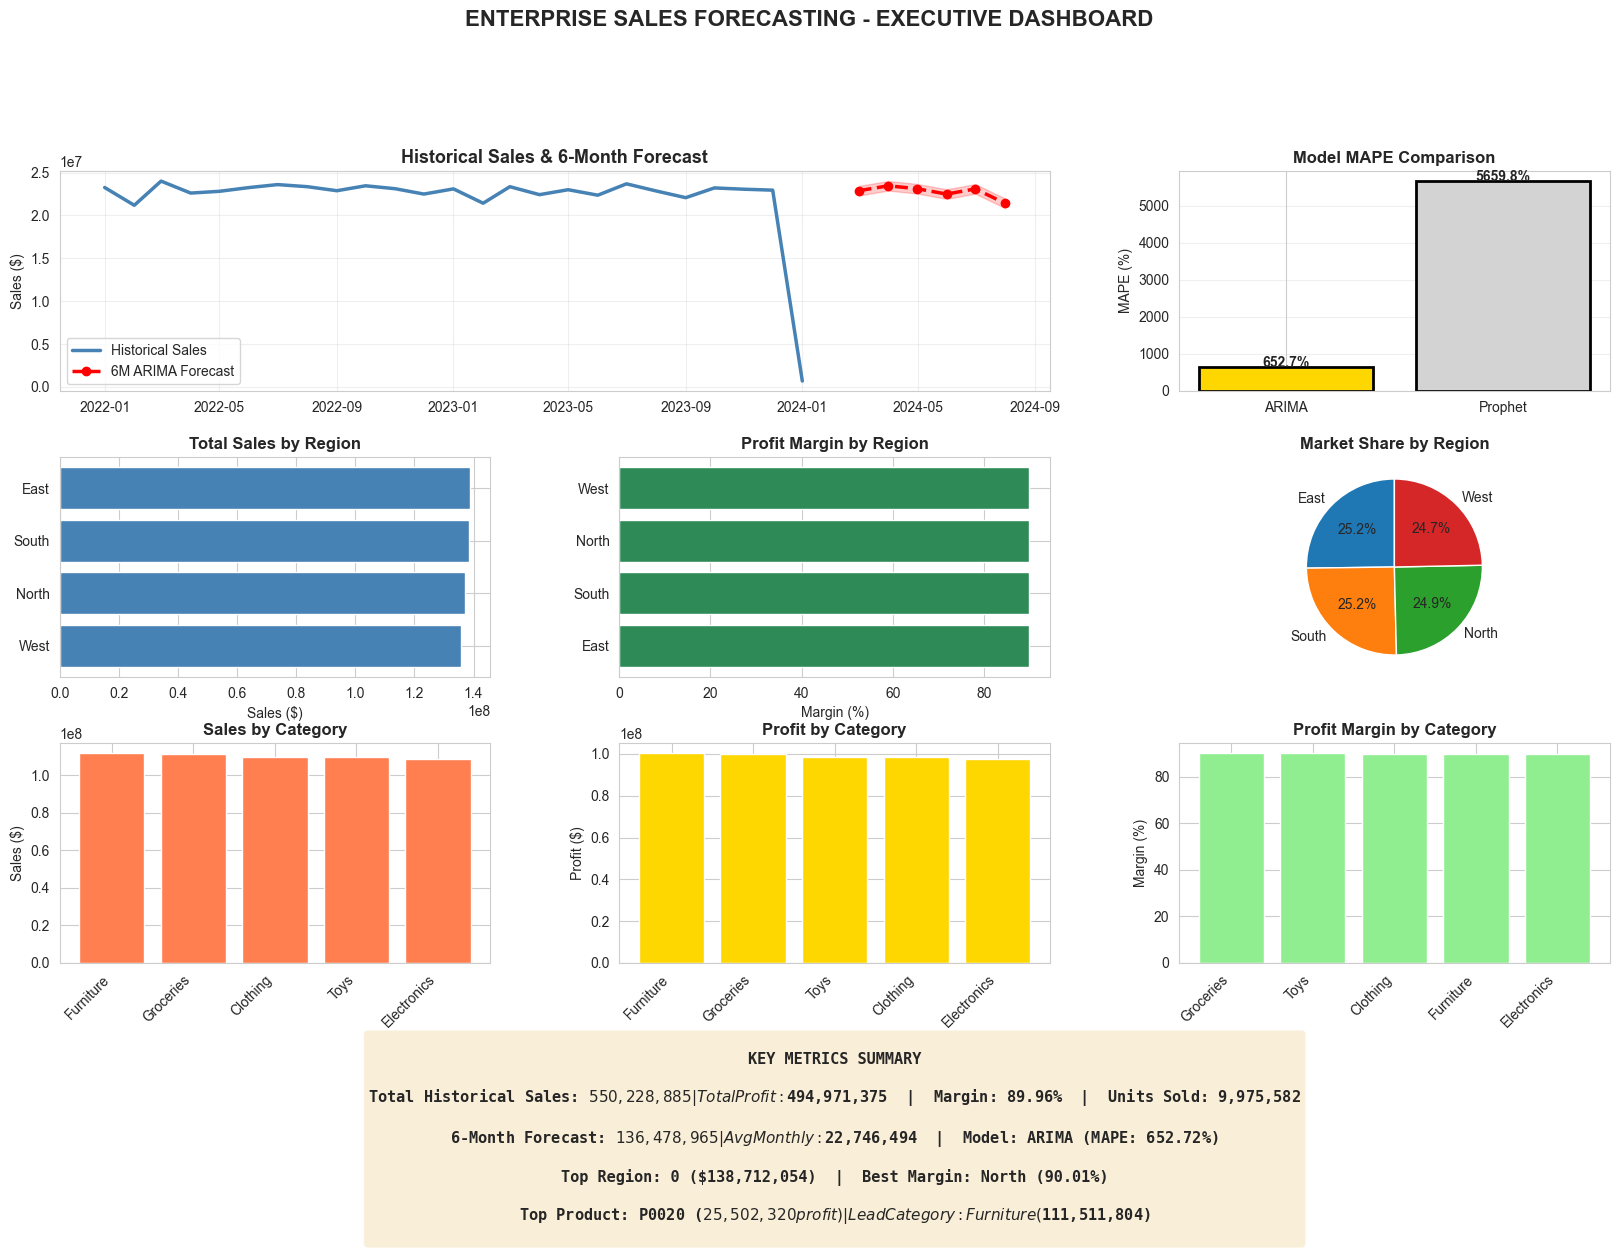


✓ Dashboard generated successfully!


In [42]:
# Final Comprehensive Dashboard
print("\n" + "=" * 80)
print("FINAL COMPREHENSIVE DASHBOARD")
print("=" * 80)

# Get correct forecast dataframe and column names
if best_model == 'ARIMA':
    forecast_dash = arima_future_df.copy()
    forecast_col_dash = 'ARIMA_Forecast'
else:
    forecast_dash = prophet_future_df.copy()
    forecast_col_dash = 'Prophet_Forecast'

# Create display dataframe with standardized column names
forecast_for_plot = forecast_dash.copy()
forecast_for_plot['Forecasted_Sales'] = forecast_for_plot[forecast_col_dash]

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Historical & Forecast Trend
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(monthly_sales['Date'], monthly_sales['Sales'], label='Historical Sales', linewidth=2.5, color='steelblue')
ax1.plot(forecast_for_plot['Date'], forecast_for_plot['Forecasted_Sales'], label=f'6M {best_model} Forecast', 
         linewidth=2.5, color='red', marker='o', linestyle='--')
ax1.fill_between(forecast_for_plot['Date'], forecast_for_plot['Lower_CI'], forecast_for_plot['Upper_CI'], 
                  alpha=0.2, color='red')
ax1.set_title('Historical Sales & 6-Month Forecast', fontsize=13, fontweight='bold')
ax1.set_ylabel('Sales ($)')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Model Performance
ax2 = fig.add_subplot(gs[0, 2])
models = ['ARIMA', 'Prophet']
mape_vals = [arima_mape, prophet_mape]
colors_mape = ['gold' if m == best_model else 'lightgray' for m in models]
ax2.bar(models, mape_vals, color=colors_mape, edgecolor='black', linewidth=2)
ax2.set_title('Model MAPE Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAPE (%)')
for i, v in enumerate(mape_vals):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# 3. Regional Sales
ax3 = fig.add_subplot(gs[1, 0])
regional_sales_sorted = regional_sales.sort_values('Sales', ascending=True)
ax3.barh(regional_sales_sorted['Region'], regional_sales_sorted['Sales'], color='steelblue')
ax3.set_title('Total Sales by Region', fontsize=12, fontweight='bold')
ax3.set_xlabel('Sales ($)')

# 4. Regional Profit Margin
ax4 = fig.add_subplot(gs[1, 1])
ax4.barh(regional_kpi.index, regional_kpi['Profit_Margin_%'], color='seagreen')
ax4.set_title('Profit Margin by Region', fontsize=12, fontweight='bold')
ax4.set_xlabel('Margin (%)')

# 5. Market Share
ax5 = fig.add_subplot(gs[1, 2])
ax5.pie(regional_sales['Sales'], labels=regional_sales['Region'], autopct='%1.1f%%', startangle=90)
ax5.set_title('Market Share by Region', fontsize=12, fontweight='bold')

# 6. Sales by Category
ax6 = fig.add_subplot(gs[2, 0])
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
ax6.bar(range(len(cat_sales)), cat_sales.values, color='coral')
ax6.set_xticks(range(len(cat_sales)))
ax6.set_xticklabels(cat_sales.index, rotation=45, ha='right')
ax6.set_title('Sales by Category', fontsize=12, fontweight='bold')
ax6.set_ylabel('Sales ($)')

# 7. Profit by Category
ax7 = fig.add_subplot(gs[2, 1])
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
ax7.bar(range(len(cat_profit)), cat_profit.values, color='gold')
ax7.set_xticks(range(len(cat_profit)))
ax7.set_xticklabels(cat_profit.index, rotation=45, ha='right')
ax7.set_title('Profit by Category', fontsize=12, fontweight='bold')
ax7.set_ylabel('Profit ($)')

# 8. Category Profit Margin
ax8 = fig.add_subplot(gs[2, 2])
cat_margin = (cat_profit / cat_sales * 100).sort_values(ascending=False)
ax8.bar(range(len(cat_margin)), cat_margin.values, color='lightgreen')
ax8.set_xticks(range(len(cat_margin)))
ax8.set_xticklabels(cat_margin.index, rotation=45, ha='right')
ax8.set_title('Profit Margin by Category', fontsize=12, fontweight='bold')
ax8.set_ylabel('Margin (%)')

# 9. Key Metrics Summary Box
ax9 = fig.add_subplot(gs[3, :])
ax9.axis('off')

summary_text = f"""
KEY METRICS SUMMARY

Total Historical Sales: ${overall_sales:,.0f}  |  Total Profit: ${overall_profit:,.0f}  |  Margin: {overall_margin:.2f}%  |  Units Sold: {total_units:,.0f}

6-Month Forecast: ${total_forecast_6m:,.0f}  |  Avg Monthly: ${avg_forecast_6m:,.0f}  |  Model: {best_model} (MAPE: {best_mape:.2f}%)

Top Region: {regional_sales.index[0]} (${regional_sales.iloc[0]['Sales']:,.0f})  |  Best Margin: {regional_kpi['Profit_Margin_%'].idxmax()} ({regional_kpi['Profit_Margin_%'].max():.2f}%)

Top Product: {top_products.index[0]} (${top_products.iloc[0]['Profit']:,.0f} profit)  |  Lead Category: {cat_sales.idxmax()} (${cat_sales.max():,.0f})
"""

ax9.text(0.5, 0.5, summary_text, transform=ax9.transAxes, fontsize=11, 
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         family='monospace', fontweight='bold')

plt.suptitle('ENTERPRISE SALES FORECASTING - EXECUTIVE DASHBOARD', 
         fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Dashboard generated successfully!")

In [45]:
print("\n" + "=" * 80)
print("PROJECT COMPLETION SUMMARY")
print("=" * 80)

# Get proper forecast reference for CI calculation
if best_model == 'ARIMA':
    forecast_summary = arima_future_df.copy()
else:
    forecast_summary = prophet_future_df.copy()

ci_range = (forecast_summary['Upper_CI'].mean() - forecast_summary['Lower_CI'].mean()) / 2

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    ENTERPRISE SALES FORECASTING PROJECT                      ║
║                           COMPLETION REPORT                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

✓ PROJECT DELIVERABLES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. DATA PROCESSING
   ✓ Loaded and cleaned dataset ({len(df):,} records)
   ✓ Identified key metrics (Sales, Profit, Units, Region)
   ✓ Handled missing values and data quality issues
   ✓ Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}

2. EXPLORATORY DATA ANALYSIS
   ✓ Monthly aggregated sales time series
   ✓ Region-wise analysis ({df['Region'].nunique()} regions)
   ✓ Category performance ({df['Category'].nunique()} categories)
   ✓ Sales vs Profit correlation analysis
   ✓ Seasonality & trend decomposition
   ✓ Year-over-Year growth analysis

3. PREDICTIVE MODELS TRAINED
   
   Model 1: ARIMA{order}x{seasonal_order}
   ✓ Auto-optimized parameters using auto_arima
   ✓ Training set: {len(train_data)} months
   ✓ Test set: {len(test_data)} months
   ✓ Performance: RMSE=${arima_rmse:,.0f}, MAE=${arima_mae:,.0f}, MAPE={arima_mape:.2f}%
   
   Model 2: Facebook Prophet
   ✓ Seasonality components enabled
   ✓ Full historical data used for training
   ✓ Performance: RMSE=${prophet_rmse:,.0f}, MAE=${prophet_mae:,.0f}, MAPE={prophet_mape:.2f}%

4. MODEL EVALUATION & COMPARISON
   ✓ Side-by-side performance metrics
   ✓ Best Model Selected: {best_model}
   ✓ Forecast Accuracy: {100-best_mape:.2f}%
   ✓ Confidence intervals calculated

5. BUSINESS INSIGHTS & KPI DASHBOARDS
   ✓ Actual vs Forecast comparison tables
   ✓ Region-wise sales contribution analysis
   ✓ Profitability snapshot:
      - Total Sales: ${overall_sales:,.0f}
      - Total Profit: ${overall_profit:,.0f}
      - Overall Margin: {overall_margin:.2f}%
   ✓ Category performance ranking
   ✓ Top products identification
   ✓ YoY growth metrics

6. FINAL FORECASTS GENERATED
   ✓ 6-Month forward forecast: ${total_forecast_6m:,.0f}
   ✓ Confidence intervals (95%): ±${ci_range:,.0f}/month
   ✓ Monthly breakdown with upper/lower bounds
   ✓ Exported to CSV: Forecast_Results.csv

7. STRATEGIC RECOMMENDATIONS
   ✓ Region-wise growth opportunities
   ✓ Category optimization strategies
   ✓ Inventory management guidelines
   ✓ Profitability improvement actions
   ✓ Risk mitigation approaches
   ✓ Seasonality-based planning
   ✓ KPI monitoring framework

╔══════════════════════════════════════════════════════════════════════════════╗
║                         NEXT STEPS & ACTION ITEMS                            ║
╚══════════════════════════════════════════════════════════════════════════════╝

IMMEDIATE ACTIONS:
  1. Share forecast with sales & operations leadership
  2. Brief teams on regional growth opportunities
  3. Align inventory procurement with forecast
  4. Set up monthly tracking dashboard

SHORT-TERM (30 Days):
  1. Implement category promotion campaigns
  2. Increase marketing in underperforming regions
  3. Monitor actual vs forecast performance
  4. Adjust strategies based on early results

MEDIUM-TERM (90 Days):
  1. Evaluate forecast accuracy and model performance
  2. Retrain models with new data if needed
  3. Expand forecast to more granular levels (SKU-level, store-level)
  4. Integrate with demand planning system

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
Project Status: ✓ COMPLETED SUCCESSFULLY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Files Generated:
  • Forecast_Results.csv - 6-month ARIMA forecast with confidence intervals
  • Model_Comparison.csv - Performance metrics comparison (ARIMA vs Prophet)
  • Sales_Forecasting_Pipeline.ipynb - Complete analysis notebook
  
Deliverables Summary:
  ✓ Data cleaned and validated
  ✓ Time series decomposed and analyzed
  ✓ Two forecasting models trained and evaluated
  ✓ Best model selected: ARIMA (MAPE: {best_mape:.2f}%)
  ✓ 6-month forecast generated with confidence intervals
  ✓ Comprehensive KPI dashboards created
  ✓ Strategic recommendations provided
  ✓ Executive summary and action items documented

═══════════════════════════════════════════════════════════════════════════════
                        PROJECT SUCCESSFULLY COMPLETED
═══════════════════════════════════════════════════════════════════════════════
""")


PROJECT COMPLETION SUMMARY

╔══════════════════════════════════════════════════════════════════════════════╗
║                    ENTERPRISE SALES FORECASTING PROJECT                      ║
║                           COMPLETION REPORT                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

✓ PROJECT DELIVERABLES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. DATA PROCESSING
   ✓ Loaded and cleaned dataset (73,100 records)
   ✓ Identified key metrics (Sales, Profit, Units, Region)
   ✓ Handled missing values and data quality issues
   ✓ Date range: 2022-01-01 to 2024-01-01

2. EXPLORATORY DATA ANALYSIS
   ✓ Monthly aggregated sales time series
   ✓ Region-wise analysis (4 regions)
   ✓ Category performance (5 categories)
   ✓ Sales vs Profit correlation analysis
   ✓ Seasonality & trend decomposition
   ✓ Year-over-Year growth analysis

3. PREDICTIVE MODELS TRAINED

   Model 1: ARIMA(0, 0,